# Hotel Market Positioning: 
### Exploring Hospitality Markets Using Location, Ratings, and Hotel Descriptions

**Dataset**: https://www.kaggle.com/datasets/raj713335/tbo-hotels-dataset

(may use this for further analysis): 
* https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe
* https://www.kaggle.com/datasets/franoisgeorgesjulien/hotels-reviews

The raw hotel dataset is not included in this repository because it exceeds GitHub’s file size limit. It can be downloaded directly from Kaggle and placed in the local `data/raw/` folder.
### Overview
For this project, I’m exploring a global hotel dataset to see how hotel supply, quality tiers, and amenities vary across different cities and countries.

I originally planned to analyze hotel descriptions and use them to group hotels by theme, but the text was too generic and messy to trust. So I shifted the project toward a better question:

**Which cities show hotel demand, existing luxury supply, and a possible gap in luxury-family travel?**

This connects to my own interest in luxury travel and hospitality. I’m especially interested in the idea that becoming a parent should not mean sacrificing high-quality travel. Families should not have to choose between luxury hotels made mostly for adults or basic child-centered hotels. There should be more options that offer enrichment, nature, culture, comfort, and engaging experiences for both children and discerning parents.

To explore this, I looked at hotel counts by location, star rating, quality tier, luxury hotel presence, and family-related amenity signals. From there, I created a shortlist of cities where family amenities appear in the broader hotel market but seem less visible among luxury hotels.

Since the dataset didn't include ADR, occupancy, reviews, traveler demographics, or tourism growth, it should be used as early screening analysis to find markets worth researching further instead of a full feasibility analysis.

In [2]:
!pip install kagglehub


  Attempting uninstall: kagglesdk

    Found existing installation: kagglesdk 0.1.16

    Uninstalling kagglesdk-0.1.16:

   ---------------------------------------- 0/2 [kagglesdk]
      Successfully uninstalled kagglesdk-0.1.16
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
path = 'data/raw/hotels.csv'

df = pd.read_csv(path, encoding='latin1')

print('Dataset path:', path)
df.head()

Dataset path: data/raw/hotels.csv


,countyCode,countyName,cityCode,cityName,HotelCode,HotelName,HotelRating,Address,Attractions,Description,FaxNumber,HotelFacilities,Map,PhoneNumber,PinCode,HotelWebsiteUrl
0,AL,Albania,106078,Albanien,1003300,De Paris Hotel,FourStar,Nr. 7 Brigada Viii Street Tirane,NaN,Hotel de Paris is a charming boutique hotel th...,42268822,Private parking Parking onsite Television in c...,41.32213|19.81665,00355 4226 5009,1000,https://www.booking.com/hotel/al/de-paris.html
1,AL,Albania,106078,Albanien,1003301,Hotel Green,FourStar,Rruga Kavajes. Kombinat Km 2. Vaqarr VaqarrTir...,NaN,"Located in a suburb of Tirana, Hotel Green is ...",35548520058,airport pick up wifi available in all areas Ai...,41.30413|19.74703,+35548520057,1041,https://www.booking.com/hotel/al/hotel-green.html
2,AL,Albania,106078,Albanien,1003302,Theranda Hotel,ThreeStar,Rr. Andon Zako Cajupi Villa 6 & 7 Villa 6 & 7T...,NaN,"Set in Tirana, 1.2 km from Skanderbeg Square, ...",00355 (0)42273689,face masks for guests available all plates cu...,41.3216|19.81199,00355 (0)42273766,1019,https://www.booking.com/hotel/al/theranda.html
3,AL,Albania,106078,Albanien,1003303,Seven Hotel,ThreeStar,"KAVAJA STREET, CLOSE TURKISH AMBASSY TIRANA",Skanderbeg Square: within 500 metre,This hotel enjoys an enviable setting in Tiran...,NaN,À la carte dinner Breakfast buffet Breakfast C...,41.328027|19.815052,NaN,1001,http://www.hotelseven-tirana.com/
4,AL,Albania,106078,Albanien,1003325,Viktoria,ThreeStar,Rruga E Elbasanit Km 4 Sauk SaukTirana,NaN,Located in a new residential area at the edge ...,+355695406986,internet services Ironing service Family rooms...,41.29125|19.85349,355 69 5406986,1000,https://www.booking.com/hotel/al/viktoria-sauk...


In [11]:
df.shape

(1010033, 16)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010033 entries, 0 to 1010032
Data columns (total 16 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   countyCode        1009121 non-null  object
 1    countyName       1010033 non-null  object
 2    cityCode         1010033 non-null  int64 
 3    cityName         1010033 non-null  object
 4    HotelCode        1010033 non-null  int64 
 5    HotelName        1010033 non-null  object
 6    HotelRating      1010033 non-null  object
 7    Address          1009931 non-null  object
 8    Attractions      484941 non-null   object
 9    Description      963028 non-null   object
 10   FaxNumber        449686 non-null   object
 11   HotelFacilities  959655 non-null   object
 12   Map              1009103 non-null  object
 13   PhoneNumber      682896 non-null   object
 14   PinCode          979054 non-null   object
 15   HotelWebsiteUrl  759915 non-null   object
dtypes: int64(2), objec

In [21]:
# Strip hidden spaces from column names so rename matches correctly
df.columns = df.columns.str.strip()

# Rename key columns into cleaner snake_case names
df = df.rename(columns={
    'countyCode': 'country_code',
    'countyName': 'country_name',
    'cityCode': 'city_code',
    'cityName': 'city_name',
    'HotelCode': 'hotel_code',
    'HotelName': 'hotel_name',
    'HotelRating': 'hotel_rating',
    'Address': 'address',
    'Attractions': 'attractions',
    'Description': 'description',
    'FaxNumber': 'fax_number',
    'HotelFacilities': 'hotel_facilities',
    'Map': 'map',
    'PinCode': 'pin_code'})

# Check that the column names updated before doing more cleaning
df.head()

,country_code,country_name,city_code,city_name,hotel_code,hotel_name,hotel_rating,address,attractions,description,fax_number,hotel_facilities,map,PhoneNumber,pin_code,HotelWebsiteUrl
0,AL,Albania,106078,Albanien,1003300,De Paris Hotel,FourStar,Nr. 7 Brigada Viii Street Tirane,NaN,Hotel de Paris is a charming boutique hotel th...,42268822,Private parking Parking onsite Television in c...,41.32213|19.81665,00355 4226 5009,1000,https://www.booking.com/hotel/al/de-paris.html
1,AL,Albania,106078,Albanien,1003301,Hotel Green,FourStar,Rruga Kavajes. Kombinat Km 2. Vaqarr VaqarrTir...,NaN,"Located in a suburb of Tirana, Hotel Green is ...",35548520058,airport pick up wifi available in all areas Ai...,41.30413|19.74703,+35548520057,1041,https://www.booking.com/hotel/al/hotel-green.html
2,AL,Albania,106078,Albanien,1003302,Theranda Hotel,ThreeStar,Rr. Andon Zako Cajupi Villa 6 & 7 Villa 6 & 7T...,NaN,"Set in Tirana, 1.2 km from Skanderbeg Square, ...",00355 (0)42273689,face masks for guests available all plates cu...,41.3216|19.81199,00355 (0)42273766,1019,https://www.booking.com/hotel/al/theranda.html
3,AL,Albania,106078,Albanien,1003303,Seven Hotel,ThreeStar,"KAVAJA STREET, CLOSE TURKISH AMBASSY TIRANA",Skanderbeg Square: within 500 metre,This hotel enjoys an enviable setting in Tiran...,NaN,À la carte dinner Breakfast buffet Breakfast C...,41.328027|19.815052,NaN,1001,http://www.hotelseven-tirana.com/
4,AL,Albania,106078,Albanien,1003325,Viktoria,ThreeStar,Rruga E Elbasanit Km 4 Sauk SaukTirana,NaN,Located in a new residential area at the edge ...,+355695406986,internet services Ironing service Family rooms...,41.29125|19.85349,355 69 5406986,1000,https://www.booking.com/hotel/al/viktoria-sauk...


In [23]:
# Map written hotel ratings into numeric values so they can be analyzed and plotted
rating_map = {
    'OneStar': 1,
    'TwoStar': 2,
    'ThreeStar': 3,
    'FourStar': 4,
    'FiveStar': 5}

df['star_rating'] = df['hotel_rating'].map(rating_map)

# Split the map field into separate latitude and longitude columns for location analysis
df[['latitude', 'longitude']] = df['map'].str.split('|', expand=True)

# Convert latitude and longitude into numbers so they can be plotted or filtered
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# Check the updated columns and first few rows before moving further
df.head()

,country_code,country_name,city_code,city_name,hotel_code,hotel_name,hotel_rating,address,attractions,description,fax_number,hotel_facilities,map,PhoneNumber,pin_code,HotelWebsiteUrl,star_rating,latitude,longitude
0,AL,Albania,106078,Albanien,1003300,De Paris Hotel,FourStar,Nr. 7 Brigada Viii Street Tirane,NaN,Hotel de Paris is a charming boutique hotel th...,42268822,Private parking Parking onsite Television in c...,41.32213|19.81665,00355 4226 5009,1000,https://www.booking.com/hotel/al/de-paris.html,4.0,41.322130,19.816650
1,AL,Albania,106078,Albanien,1003301,Hotel Green,FourStar,Rruga Kavajes. Kombinat Km 2. Vaqarr VaqarrTir...,NaN,"Located in a suburb of Tirana, Hotel Green is ...",35548520058,airport pick up wifi available in all areas Ai...,41.30413|19.74703,+35548520057,1041,https://www.booking.com/hotel/al/hotel-green.html,4.0,41.304130,19.747030
2,AL,Albania,106078,Albanien,1003302,Theranda Hotel,ThreeStar,Rr. Andon Zako Cajupi Villa 6 & 7 Villa 6 & 7T...,NaN,"Set in Tirana, 1.2 km from Skanderbeg Square, ...",00355 (0)42273689,face masks for guests available all plates cu...,41.3216|19.81199,00355 (0)42273766,1019,https://www.booking.com/hotel/al/theranda.html,3.0,41.321600,19.811990
3,AL,Albania,106078,Albanien,1003303,Seven Hotel,ThreeStar,"KAVAJA STREET, CLOSE TURKISH AMBASSY TIRANA",Skanderbeg Square: within 500 metre,This hotel enjoys an enviable setting in Tiran...,NaN,À la carte dinner Breakfast buffet Breakfast C...,41.328027|19.815052,NaN,1001,http://www.hotelseven-tirana.com/,3.0,41.328027,19.815052
4,AL,Albania,106078,Albanien,1003325,Viktoria,ThreeStar,Rruga E Elbasanit Km 4 Sauk SaukTirana,NaN,Located in a new residential area at the edge ...,+355695406986,internet services Ironing service Family rooms...,41.29125|19.85349,355 69 5406986,1000,https://www.booking.com/hotel/al/viktoria-sauk...,3.0,41.291250,19.853490


In [26]:
# Count missing values so I can see which columns may need attention
df.isna().sum().sort_values(ascending=False)

fax_number          560347
attractions         525092
PhoneNumber         327137
star_rating         315668
HotelWebsiteUrl     250118
hotel_facilities     50378
description          47005
pin_code             30979
latitude               932
map                    930
longitude              930
country_code           912
address                102
country_name             0
hotel_rating             0
hotel_name               0
hotel_code               0
city_name                0
city_code                0
dtype: int64

In [28]:
# Create a quick data quality summary for each column
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().round(3),
    'unique_values': df.nunique()})

summary.sort_values('missing_pct', ascending=False)

,dtype,missing,missing_pct,unique_values
fax_number,object,560347,0.555,292389
attractions,object,525092,0.520,357697
PhoneNumber,object,327137,0.324,433346
star_rating,float64,315668,0.313,5
HotelWebsiteUrl,object,250118,0.248,566539
hotel_facilities,object,50378,0.050,656894
description,object,47005,0.047,732444
pin_code,object,30979,0.031,142146
latitude,float64,932,0.001,702993
map,object,930,0.001,743246


In [29]:
# Drop contact/detail columns that do not support the main market positioning story
df = df.drop(columns=[
    'fax_number',
    'PhoneNumber',
    'pin_code'], errors='ignore')

# Keep rows with location data because city and country analysis depends on these fields
df = df.dropna(subset=['country_name', 'city_name'])

# Check the updated shape after dropping low-value columns
df.shape

(1010033, 16)

### Hotel Ratings

In [31]:
# Check rating labels before converting them into numeric star ratings
df['star_rating'].value_counts(dropna=False)

star_rating
3.0    352613
NaN    315668
2.0    159754
4.0    130862
1.0     28734
5.0     22402
Name: count, dtype: int64

In [32]:
# Keep missing ratings for now so I do not accidentally remove useful hotels from the market analysis
df['rating_group'] = df['star_rating'].fillna('unrated')

In [33]:
# Create a rated-only version for charts that need numeric star ratings
df_rated = df.dropna(subset=['star_rating']).copy()

In [34]:
df_rated.head()

,country_code,country_name,city_code,city_name,hotel_code,hotel_name,hotel_rating,address,attractions,description,hotel_facilities,map,HotelWebsiteUrl,star_rating,latitude,longitude,rating_group
0,AL,Albania,106078,Albanien,1003300,De Paris Hotel,FourStar,Nr. 7 Brigada Viii Street Tirane,NaN,Hotel de Paris is a charming boutique hotel th...,Private parking Parking onsite Television in c...,41.32213|19.81665,https://www.booking.com/hotel/al/de-paris.html,4.0,41.322130,19.816650,4.0
1,AL,Albania,106078,Albanien,1003301,Hotel Green,FourStar,Rruga Kavajes. Kombinat Km 2. Vaqarr VaqarrTir...,NaN,"Located in a suburb of Tirana, Hotel Green is ...",airport pick up wifi available in all areas Ai...,41.30413|19.74703,https://www.booking.com/hotel/al/hotel-green.html,4.0,41.304130,19.747030,4.0
2,AL,Albania,106078,Albanien,1003302,Theranda Hotel,ThreeStar,Rr. Andon Zako Cajupi Villa 6 & 7 Villa 6 & 7T...,NaN,"Set in Tirana, 1.2 km from Skanderbeg Square, ...",face masks for guests available all plates cu...,41.3216|19.81199,https://www.booking.com/hotel/al/theranda.html,3.0,41.321600,19.811990,3.0
3,AL,Albania,106078,Albanien,1003303,Seven Hotel,ThreeStar,"KAVAJA STREET, CLOSE TURKISH AMBASSY TIRANA",Skanderbeg Square: within 500 metre,This hotel enjoys an enviable setting in Tiran...,À la carte dinner Breakfast buffet Breakfast C...,41.328027|19.815052,http://www.hotelseven-tirana.com/,3.0,41.328027,19.815052,3.0
4,AL,Albania,106078,Albanien,1003325,Viktoria,ThreeStar,Rruga E Elbasanit Km 4 Sauk SaukTirana,NaN,Located in a new residential area at the edge ...,internet services Ironing service Family rooms...,41.29125|19.85349,https://www.booking.com/hotel/al/viktoria-sauk...,3.0,41.291250,19.853490,3.0


In [35]:
# Group star ratings into broader tiers so the market story is easier to read
tier_map = {
    1.0: 'budget',
    2.0: 'budget',
    3.0: 'mid_range',
    4.0: 'upscale',
    5.0: 'luxury'}

df['quality_tier'] = df['star_rating'].map(tier_map).fillna('unrated')

In [36]:
# Check how hotels are distributed across quality tiers
df['quality_tier'].value_counts()

quality_tier
mid_range    352613
unrated      315668
budget       188488
upscale      130862
luxury        22402
Name: count, dtype: int64

In [37]:
# Convert tier counts into percentages so the distribution is easier to compare
df['quality_tier'].value_counts(normalize=True).mul(100).round(1)

quality_tier
mid_range    34.9
unrated      31.3
budget       18.7
upscale      13.0
luxury        2.2
Name: proportion, dtype: float64

Text(0, 0.5, 'Number of Hotels')

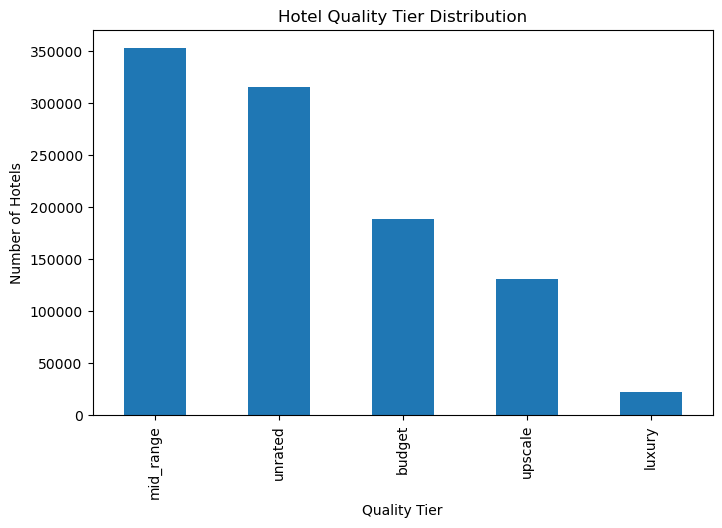

In [39]:
# Plot hotel quality tiers to see the overall mix in the dataset
ax = df['quality_tier'].value_counts().plot(kind='bar', figsize=(8, 5))

ax.set_title('Hotel Quality Tier Distribution')
ax.set_xlabel('Quality Tier')
ax.set_ylabel('Number of Hotels')

### Analyis: 

The dataset appears to be concentrated mostly in mid_range hotels. I kept unrated hotels in the dataset because they make up a large share of the records, and dropping them this early could remove useful market information.

## Hotels by Country and City

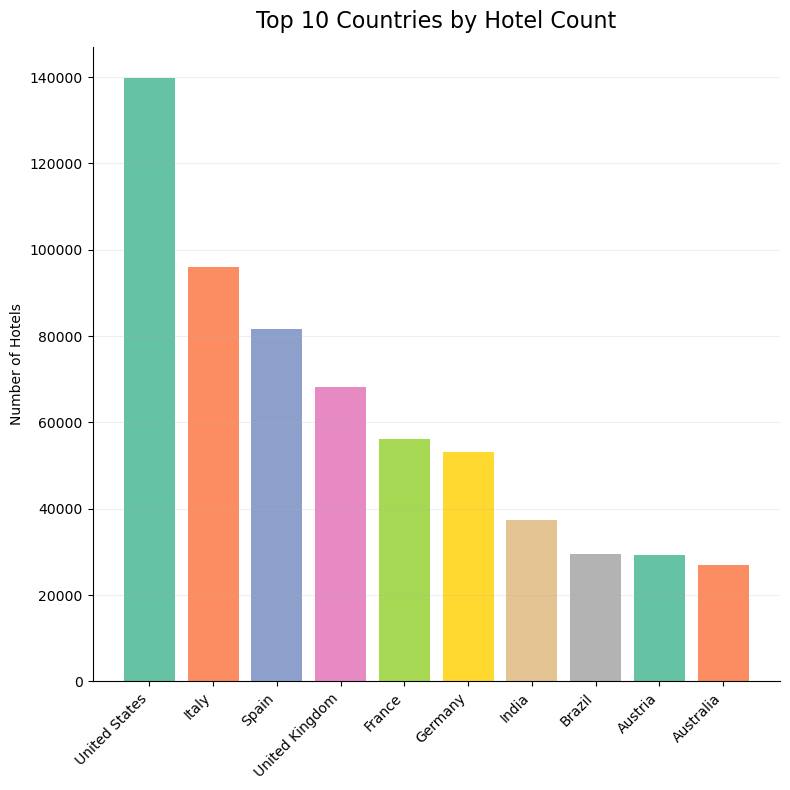

In [215]:
# Count the top 10 countries by hotel volume
top_countries = df['country_name'].value_counts().head(10)

# Use soft colors that fit the presentation style
colors = sns.color_palette('Set2', n_colors=len(top_countries))

fig, ax = plt.subplots(figsize=(8, 8))

ax.bar(top_countries.index, top_countries.values, color=colors)

ax.set_title('Top 10 Countries by Hotel Count', fontsize=16, pad=14)
ax.set_xlabel('')
ax.set_ylabel('Number of Hotels')

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('top_10_countries_hotel_count.png', dpi=300, bbox_inches='tight')
plt.show()

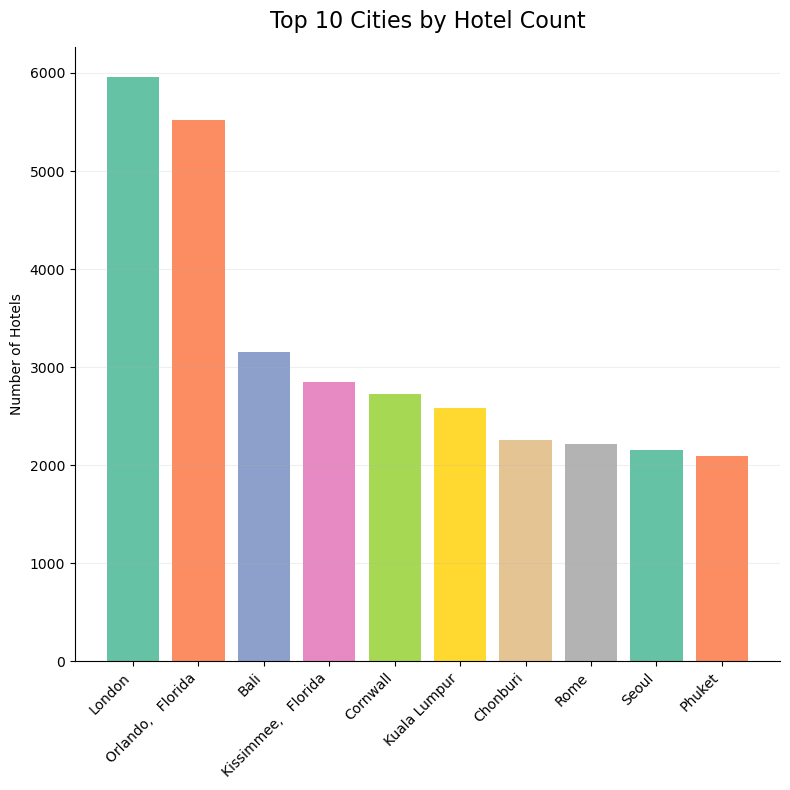

In [221]:
# Count the top 10 cities by hotel volume
top_cities = df['city_name'].value_counts().head(10)

# Use soft colors that fit the presentation style
colors = sns.color_palette('Set2', n_colors=len(top_cities))

fig, ax = plt.subplots(figsize=(8,8))

ax.bar(top_cities.index, top_cities.values, color=colors)

ax.set_title('Top 10 Cities by Hotel Count', fontsize=16, pad=14)
ax.set_xlabel('')
ax.set_ylabel('Number of Hotels')

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('top_10_cities_hotel_count.png', dpi=300, bbox_inches='tight')
plt.show()

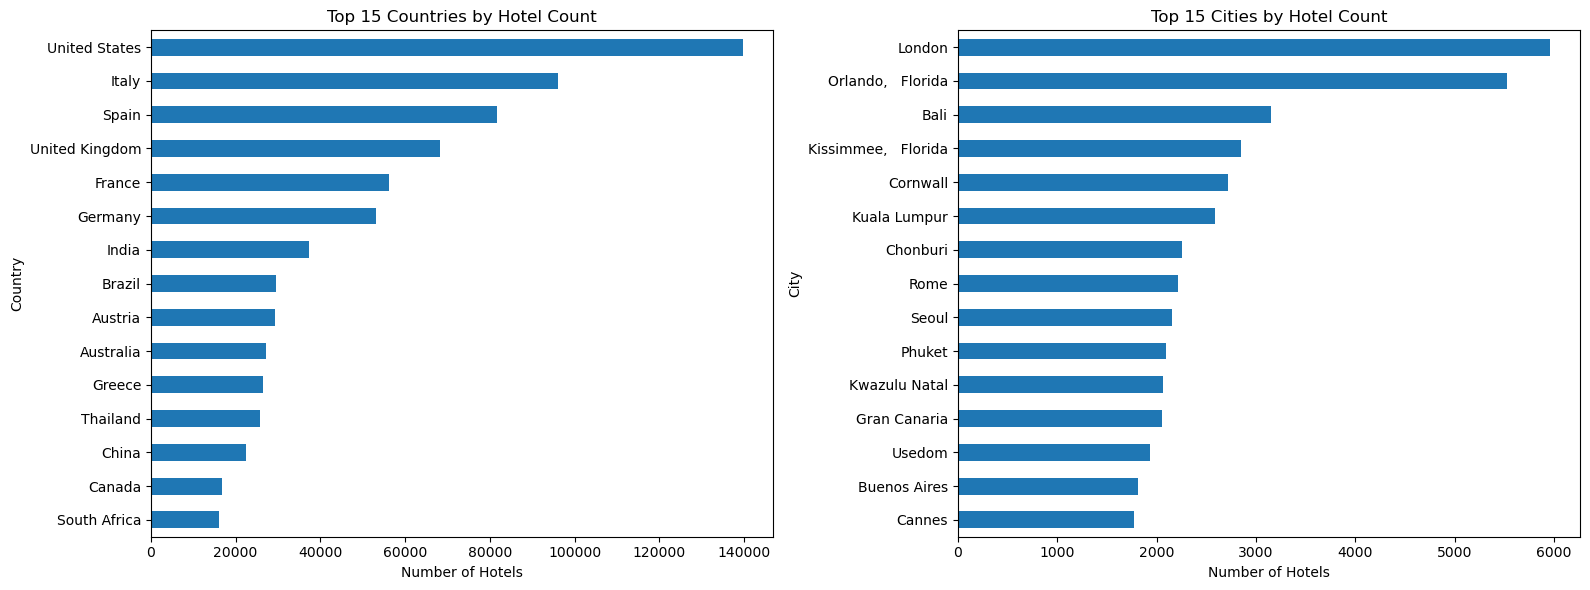

In [220]:
# Count hotels by country and city so I can compare the biggest markets side by side
top_countries = df['country_name'].value_counts().head(15)
top_cities = df['city_name'].value_counts().head(15)

# Plot country and city counts together to keep the location overview compact
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

top_countries.sort_values().plot(kind='barh', ax=ax[0])
ax[0].set_title('Top 15 Countries by Hotel Count')
ax[0].set_xlabel('Number of Hotels')
ax[0].set_ylabel('Country')

top_cities.sort_values().plot(kind='barh', ax=ax[1])
ax[1].set_title('Top 15 Cities by Hotel Count')
ax[1].set_xlabel('Number of Hotels')
ax[1].set_ylabel('City')

plt.tight_layout()
plt.show()

### Analysis: 
This gives me a quick sense of where the dataset is strongest. Since I’m looking for market gaps, I’ll get better comparisons from cities and countries with enough hotels to actually show a pattern.

### Analyze Ratings / Quality by Country

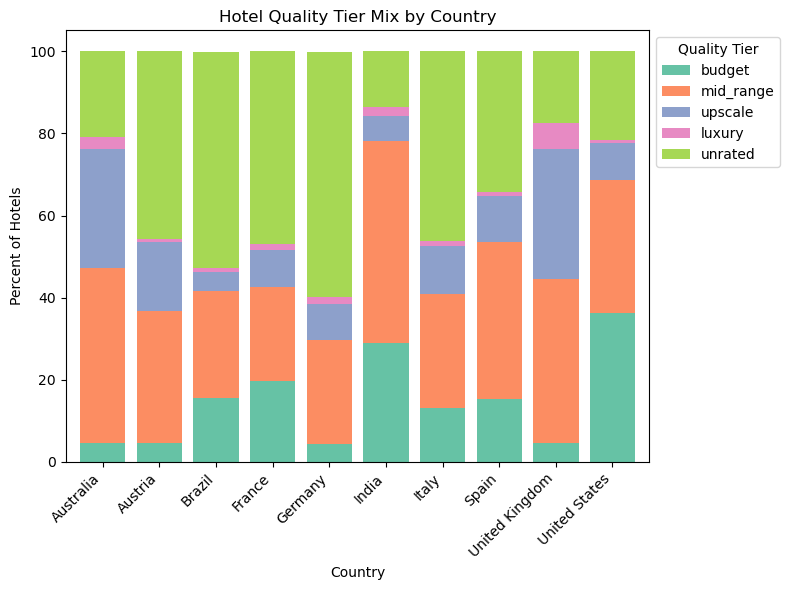

In [222]:
# Set the tier order so the stacked bars read from lower to higher quality
tier_order = ['budget', 'mid_range', 'upscale', 'luxury', 'unrated']
country_tiers = country_tiers.reindex(columns=tier_order)

colors = sns.color_palette('Set2', n_colors=len(tier_order))

# stacked bar chart
ax = country_tiers.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.8,
    color=colors)

ax.set_title('Hotel Quality Tier Mix by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Percent of Hotels')
ax.legend(title='Quality Tier', bbox_to_anchor=(1, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Hotel quality mix varies a lot by country. I think it's interesting that Germany has such a high volume of unrated hotels, while India, Australia, and the UK have a much higher rate of rated hotels.

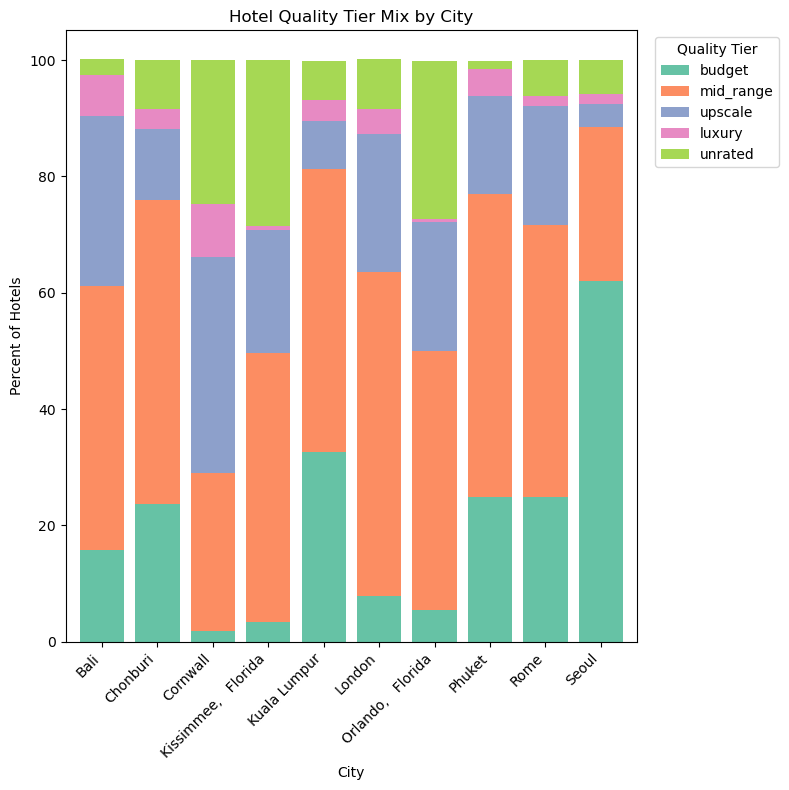

In [240]:
# Limit to the top cities
top_city_names = df['city_name'].value_counts().head(10).index
city_df = df[df['city_name'].isin(top_city_names)].copy()

# Create a percent table so each city adds up to 100%
city_tiers = pd.crosstab(
    city_df['city_name'],
    city_df['quality_tier'],
    normalize='index').mul(100).round(1)

# Reorder columns so the quality tiers read from lowest to highest
tier_order = ['budget', 'mid_range', 'upscale', 'luxury', 'unrated']
city_tiers = city_tiers.reindex(columns=tier_order)

ax = city_tiers.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 8),
    width=0.8,
    color=colors)

ax.set_title('Hotel Quality Tier Mix by City')
ax.set_xlabel('City')
ax.set_ylabel('Percent of Hotels')
ax.legend(title='Quality Tier', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Luxury Hotels

In [62]:
# Filter to luxury hotels so I can see where 5-star supply is concentrated
luxury = df[df['quality_tier'] == 'luxury'].copy()

# Count luxury hotels by city to find the highest-volume luxury markets
luxury_city_counts = luxury['city_name'].value_counts().head(15)

luxury_city_counts

city_name
London             251
Cornwall           247
Dubai              230
Bali               223
Kappeln            184
Western Cape       170
Koh Samui          123
Gwynedd            115
Cape Town          110
Phuket              97
Kuala Lumpur        94
Sharm el Sheikh     90
Johannesburg        82
Chonburi            74
Siem Reap           73
Name: count, dtype: int64

In [66]:
# Summarize luxury hotel count by city and country
city_summary = df.groupby(['country_name', 'city_name']).agg(
    total_hotels=('hotel_code', 'count'),
    luxury_hotels=('quality_tier', lambda x: (x == 'luxury').sum())).reset_index()

# Calculate luxury share
city_summary['luxury_pct'] = (
    city_summary['luxury_hotels'] / city_summary['total_hotels'] * 100).round(1)

# Keep cities with enough hotels so the percentages are more meaningful
city_summary = city_summary[city_summary['total_hotels'] >= 50]

# Sort by luxury hotel count to find the biggest luxury hotel markets
city_summary.sort_values('luxury_hotels', ascending=False).head(15)

,country_name,city_name,total_hotels,luxury_hotels,luxury_pct
35332,United Kingdom,London,5962,251,4.2
34662,United Kingdom,Cornwall,2721,247,9.1
34153,United Arab Emirates,Dubai,1448,230,15.9
18639,Indonesia,Bali,3090,222,7.2
14189,Germany,Kappeln,281,184,65.5
29105,South Africa,Western Cape,1357,170,12.5
33525,Thailand,Koh Samui,1588,123,7.7
34990,United Kingdom,Gwynedd,1419,115,8.1
28826,South Africa,Cape Town,804,110,13.7
33590,Thailand,Phuket,2094,97,4.6


In [225]:
# Summarize luxury hotel count and share by city and country
city_summary = df.groupby(['country_name', 'city_name']).agg(
    total_hotels=('hotel_code', 'count'),
    luxury_hotels=('quality_tier', lambda x: (x == 'luxury').sum())
).reset_index()

# Calculate luxury share by market
city_summary['luxury_pct'] = (
    city_summary['luxury_hotels'] / city_summary['total_hotels'] * 100
).round(1)

# Keep markets with enough hotels so the percentages are more meaningful
city_summary = city_summary[city_summary['total_hotels'] >= 50].copy()

# Create a market label for cleaner plotting
city_summary['market'] = city_summary['city_name'] + ', ' + city_summary['country_name']

# Pull the top luxury hotel markets
top_luxury = (
    city_summary
    .sort_values('luxury_hotels', ascending=False)
    .head(10)
    .sort_values('luxury_hotels'))

In [70]:
df.columns

Index(['country_code', 'country_name', 'city_code', 'city_name', 'hotel_code',
       'hotel_name', 'hotel_rating', 'address', 'attractions', 'description',
       'hotel_facilities', 'map', 'HotelWebsiteUrl', 'star_rating', 'latitude',
       'longitude', 'rating_group', 'quality_tier'],
      dtype='object')

In [72]:
# Summarize luxury hotel count by city and country
city_summary = df.groupby(['country_name', 'city_name']).agg(
    total_hotels=('hotel_code', 'count'),
    luxury_hotels=('quality_tier', lambda x: (x == 'luxury').sum())).reset_index()

# Calculate luxury share
city_summary['luxury_pct'] = (
    city_summary['luxury_hotels'] / city_summary['total_hotels'] * 100).round(1)

# Sort by luxury hotel count to find the biggest luxury hotel markets
city_summary.sort_values('luxury_pct', ascending=False).head(15)

,country_name,city_name,total_hotels,luxury_hotels,luxury_pct
34510,United Kingdom,Burton,1,1,100.0
2798,Azerbaijan,Qabala,2,2,100.0
35100,United Kingdom,Horseman's Green,1,1,100.0
7467,Estonia,Kõue,1,1,100.0
35868,United Kingdom,Stadhampton,1,1,100.0
24016,Malta,Attard,1,1,100.0
28439,Saudi Arabia,Farasan Island,1,1,100.0
24069,Mauritius,Chemin Grenier,1,1,100.0
28544,Seychelles,Bird Island,1,1,100.0
28546,Seychelles,Cousine Island,1,1,100.0


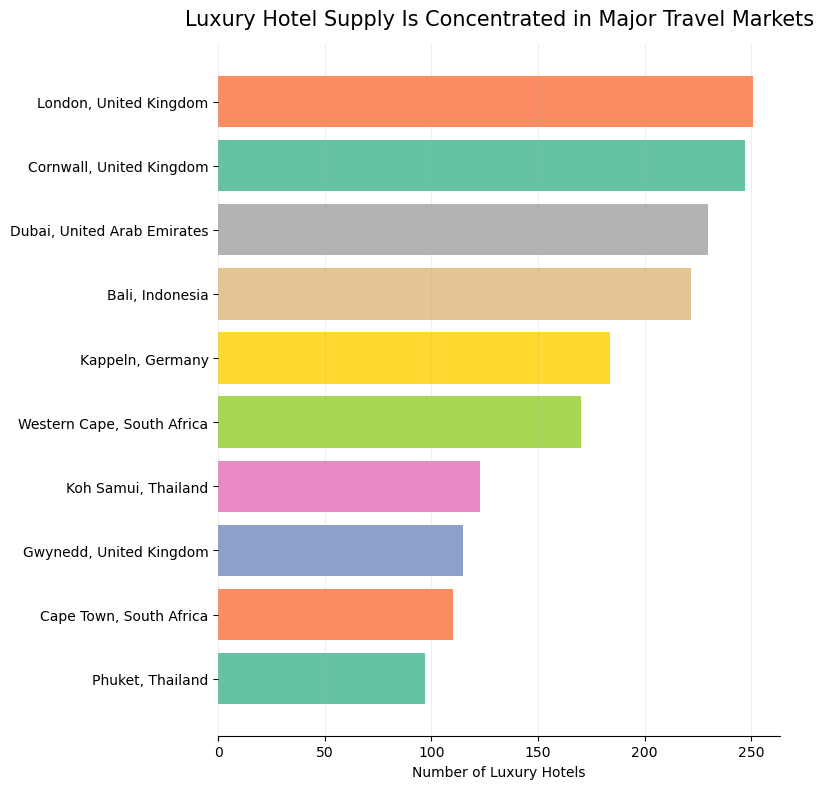

In [230]:
# Plot luxury hotel count for the top luxury markets
colors = sns.color_palette('Set2', n_colors=len(top_luxury))

fig, ax = plt.subplots(figsize=(8,8))

ax.barh(top_luxury['market'], top_luxury['luxury_hotels'], color=colors)

ax.set_title('Luxury Hotel Supply Is Concentrated in Major Travel Markets', fontsize=15, pad=14)
ax.set_xlabel('Number of Luxury Hotels')
ax.set_ylabel('')

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('top_luxury_markets_count.png', dpi=300, bbox_inches='tight')
plt.show()

In [231]:
city_summary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3823 entries, 0 to 42804
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country_name   3823 non-null   object 
 1   city_name      3823 non-null   object 
 2   total_hotels   3823 non-null   int64  
 3   luxury_hotels  3823 non-null   int64  
 4   luxury_pct     3823 non-null   float64
 5   market         3823 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 209.1+ KB


### Searching Luxury Hotels by City (code template)

In [80]:
# Search luxury hotels by city and optional country
city = 'dublin'
country = None

luxury_search = df[
    (df['quality_tier'] == 'luxury') &
    (df['city_name'].str.contains(city, case=False, na=False))].copy()

if country:
    luxury_search = luxury_search[
        luxury_search['country_name'].str.contains(country, case=False, na=False)]

luxury_search[[
    'country_name',
    'city_name',
    'hotel_name',
    'star_rating',
    'address',
    'description',
    'hotel_facilities',
    'latitude',
    'longitude']].head(5)

,country_name,city_name,hotel_name,star_rating,address,description,hotel_facilities,latitude,longitude
403809,Ireland(Republic of),Dublin,The Marker Hotel,5.0,Grand Canal Square Docklands DocklandsDublin 2...,<p>HeadLine : In Dublin (City Centre Dublin)</...,Conference space size (feet) - 603 Concierge s...,53.344376,-6.239304
403826,Ireland(Republic of),Dublin,Luttrellstown Castle Resort,5.0,Castleknock Dublin 15Dublin,<p>HeadLine : In Woodlands</p><p>Location : Wi...,Safe-deposit box at front desk Barbecue grill(...,53.373677,-6.431300
403882,Ireland(Republic of),Dublin,Conrad Dublin,5.0,Earlsfort Terrace Dublin 2,<p>HeadLine : Near St. Stephen s Green</p><p>L...,Dry cleaning/laundry service Long-term parking...,53.334988,-6.257932
403920,Ireland(Republic of),Dublin,InterContinental Dublin,5.0,Simmonscourt Road BallsbridgeDublin 4D04 A9K8 ...,<p>HeadLine : Near RDS Main Arena</p><p>Locati...,Gift shops or newsstand Dry cleaning/laundry s...,53.326310,-6.225539
403928,Ireland(Republic of),Dublin,The Shelbourne Dublin A Renaissance Hotel,5.0,27 St. Stephen's Green Dublin 2Dublin,<p>HeadLine : Near Trinity College</p><p>Locat...,Conference space size (feet) - 4977 Concierge ...,53.339000,-6.256089


### Exploring gaps - high hotel volume, low luxury count

In [83]:
# Summarize hotel supply by country and city so each market has one row
market_summary = df.groupby(['country_name', 'city_name']).agg(
    total_hotels=('hotel_code', 'count'),
    luxury_hotels=('quality_tier', lambda x: (x == 'luxury').sum()),
    upscale_hotels=('quality_tier', lambda x: (x == 'upscale').sum()),
    mid_range_hotels=('quality_tier', lambda x: (x == 'mid_range').sum()),
    budget_hotels=('quality_tier', lambda x: (x == 'budget').sum()),
    unrated_hotels=('quality_tier', lambda x: (x == 'unrated').sum())).reset_index()

# Add percentages so to compare markets of different sizes more fairly
market_summary['luxury_pct'] = (market_summary['luxury_hotels'] / market_summary['total_hotels'] * 100).round(1)
market_summary['upscale_pct'] = (market_summary['upscale_hotels'] / market_summary['total_hotels'] * 100).round(1)
market_summary['unrated_pct'] = (market_summary['unrated_hotels'] / market_summary['total_hotels'] * 100).round(1)

market_summary.head()

,country_name,city_name,total_hotels,luxury_hotels,upscale_hotels,mid_range_hotels,budget_hotels,unrated_hotels,luxury_pct,upscale_pct,unrated_pct
0,Albania,Albanien,800,26,162,262,54,296,3.2,20.2,37.0
1,Albania,Berat,70,0,10,22,6,32,0.0,14.3,45.7
2,Albania,Borsh,22,0,3,4,1,14,0.0,13.6,63.6
3,Albania,Bërxullë,1,0,0,1,0,0,0.0,0.0,0.0
4,Albania,Dhërmi,65,2,10,18,3,32,3.1,15.4,49.2


In [84]:
# Find larger hotel markets with a lower luxury share
possible_luxury_gaps = market_summary[
    (market_summary['total_hotels'] >= 50) &
    (market_summary['luxury_pct'] <= 5)].sort_values(['total_hotels', 'luxury_pct'], ascending=[False, True])

possible_luxury_gaps.head(20)

,country_name,city_name,total_hotels,luxury_hotels,upscale_hotels,mid_range_hotels,budget_hotels,unrated_hotels,luxury_pct,upscale_pct,unrated_pct
35332,United Kingdom,London,5962,251,1416,3312,469,514,4.2,23.8,8.6
40543,United States,"Orlando, Florida",5523,30,1220,2465,298,1510,0.5,22.1,27.3
39225,United States,"Kissimmee, Florida",2848,17,602,1318,96,815,0.6,21.1,28.6
23907,Malaysia,Kuala Lumpur,2588,94,213,1259,846,176,3.6,8.2,6.8
33468,Thailand,Chonburi,2258,74,275,1184,532,193,3.3,12.2,8.5
22035,Italy,Rome,2217,40,454,1037,550,136,1.8,20.5,6.1
29183,South Korea,Seoul,2156,39,85,571,1337,124,1.8,3.9,5.8
33590,Thailand,Phuket,2094,97,352,1092,522,31,4.6,16.8,1.5
28928,South Africa,Kwazulu Natal,2069,43,317,730,52,927,2.1,15.3,44.8
30210,Spain,Gran Canaria,2055,28,188,854,302,683,1.4,9.1,33.2


In [86]:
possible_luxury_gaps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3318 entries, 35332 to 35863
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_name      3318 non-null   object 
 1   city_name         3318 non-null   object 
 2   total_hotels      3318 non-null   int64  
 3   luxury_hotels     3318 non-null   int64  
 4   upscale_hotels    3318 non-null   int64  
 5   mid_range_hotels  3318 non-null   int64  
 6   budget_hotels     3318 non-null   int64  
 7   unrated_hotels    3318 non-null   int64  
 8   luxury_pct        3318 non-null   float64
 9   upscale_pct       3318 non-null   float64
 10  unrated_pct       3318 non-null   float64
dtypes: float64(3), int64(6), object(2)
memory usage: 311.1+ KB


In [89]:
# Create a working copy to test a simple market opportunity score
market_score = market_summary.copy()

# Filter to markets with enough hotel records to make the comparison useful
market_score = market_score[market_score['total_hotels'] >= 25].copy()

# Score markets where hotel volume is high but luxury supply is low
market_score['luxury_gap_score'] = (
    market_score['total_hotels'] * (1 - market_score['luxury_pct'] / 100)).round(1)

# Sort to find larger markets with lower luxury representation
luxury_gap_markets = market_score.sort_values(
    'luxury_gap_score',
    ascending=False)

luxury_gap_markets.head()

,country_name,city_name,total_hotels,luxury_hotels,upscale_hotels,mid_range_hotels,budget_hotels,unrated_hotels,luxury_pct,upscale_pct,unrated_pct,luxury_gap_score
35332,United Kingdom,London,5962,251,1416,3312,469,514,4.2,23.8,8.6,5711.6
40543,United States,"Orlando, Florida",5523,30,1220,2465,298,1510,0.5,22.1,27.3,5495.4
18639,Indonesia,Bali,3090,222,910,1414,487,57,7.2,29.4,1.8,2867.5
39225,United States,"Kissimmee, Florida",2848,17,602,1318,96,815,0.6,21.1,28.6,2830.9
23907,Malaysia,Kuala Lumpur,2588,94,213,1259,846,176,3.6,8.2,6.8,2494.8


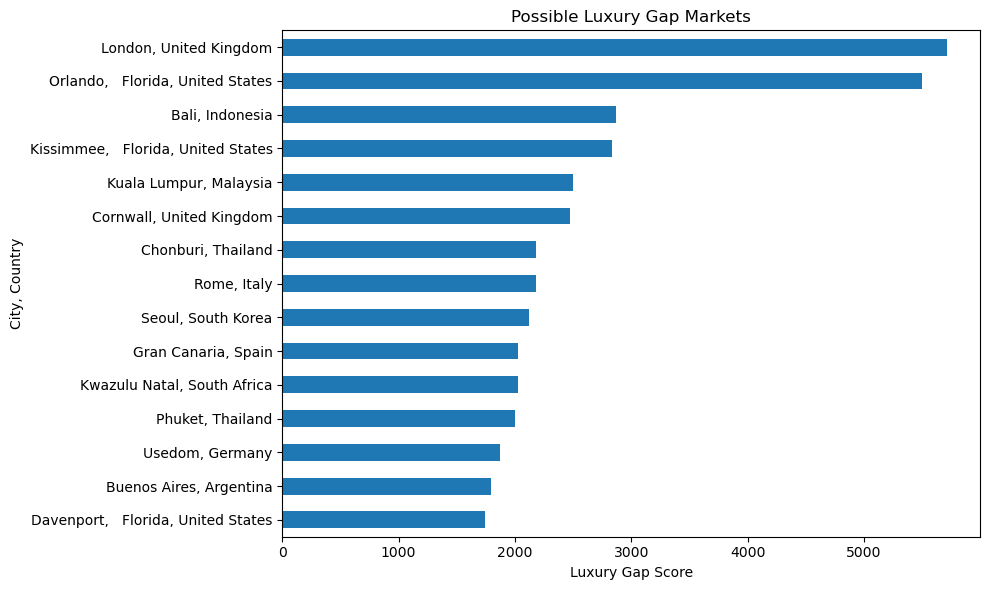

In [90]:
# Create a market label so city and country stay together in the chart
top_gaps = luxury_gap_markets.head(15).copy()
top_gaps['market'] = top_gaps['city_name'] + ', ' + top_gaps['country_name']

# Plot possible luxury gap markets based on volume and low luxury share
ax = top_gaps.sort_values('luxury_gap_score').plot(
    x='market',
    y='luxury_gap_score',
    kind='barh',
    figsize=(10, 6),
    legend=False)

ax.set_title('Possible Luxury Gap Markets')
ax.set_xlabel('Luxury Gap Score')
ax.set_ylabel('City, Country')

plt.tight_layout()
plt.show()

### Analysis:

Using this strategy to find a gap wasn't too helpful since it's showing saturated/competitive markets. 

A better strategy is to look for mid-volume markets with decent upscale/mid-range supply but low luxury share. If a city already supports many mid-range and upscale hotels, there may be proven travel demand and spending power. If luxury is still low, that could mean there's room for a more elevated concept.

It filters out tiny markets with no proven demand and avoids automatically favoring massive saturated cities.

**Limitations:** This dataset does not show occupancy, ADR, RevPAR, tourism growth, seasonality, hotel age, or type. So these are just  ***potential*** gap markets, not true investment opportunities.

A better score could prioritize:

moderate total hotel count + high upscale/mid-range share + low luxury share + low unrated share

In [95]:
df['description']

0          Hotel de Paris is a charming boutique hotel th...
1          Located in a suburb of Tirana, Hotel Green is ...
2          Set in Tirana, 1.2 km from Skanderbeg Square, ...
3          This hotel enjoys an enviable setting in Tiran...
4          Located in a new residential area at the edge ...
                                 ...                        
1010028                                                  NaN
1010029    <p>HeadLine : In a national park</p><p>Locatio...
1010030    Featuring garden views, Victoria Falls Holiday...
1010031    <p>HeadLine : In Victoria Falls</p><p>Location...
1010032    <p>HeadLine : In a national park</p><p>Locatio...
Name: description, Length: 1010033, dtype: object

In [92]:
# Combine description and facilities so each hotel has one text field for positioning analysis
df['hotel_text'] = (
    df['description'].fillna('') + ' ' + 
    df['hotel_facilities'].fillna('')).str.lower()

In [94]:
# Define keyword groups so I can tag hotels by the language they use
theme_keywords = {
    'family': ['family', 'children', 'kids', 'child', 'playground', 'babysitting'],
    'business': ['business', 'conference', 'meeting', 'desk', 'work', 'airport'],
    'luxury': ['luxury', 'elegant', 'premium', 'exclusive', 'spa', 'suite'],
    'wellness': ['spa', 'wellness', 'massage', 'fitness', 'sauna', 'yoga'],
    'resort': ['resort', 'beach', 'pool', 'leisure', 'villa', 'garden'],
    'budget': ['budget', 'basic', 'affordable', 'hostel', 'guesthouse']}

In [97]:
# Tag hotels when their text contains keywords from each positioning theme
for theme, words in theme_keywords.items():
    pattern = '|'.join(words)
    df[f'{theme}_tag'] = df['hotel_text'].str.contains(pattern, na=False)

In [98]:
# Count how many hotels match each theme
theme_cols = [col for col in df.columns if col.endswith('_tag')]

df[theme_cols].sum().sort_values(ascending=False)

business_tag    833330
resort_tag      726374
wellness_tag    404011
luxury_tag      375675
family_tag      357672
budget_tag       56969
dtype: int64

In [99]:
# Convert theme counts into percentages so the theme mix is easier to understand
(df[theme_cols].mean() * 100).round(1).sort_values(ascending=False)

business_tag    82.5
resort_tag      71.9
wellness_tag    40.0
luxury_tag      37.2
family_tag      35.4
budget_tag       5.6
dtype: float64

In [102]:
# Show full text so I can audit whether the keyword tags are actually accurate
pd.set_option('display.max_colwidth', None)

tag = 'family_tag'

df[df[tag]][[
    'country_name',
    'city_name',
    'hotel_name',
    'description',
    'hotel_facilities']].sample(10, random_state=42)

,country_name,city_name,hotel_name,description,hotel_facilities
615708,Russian Federation,Kemerovo,Crystall De Luxe,"Featuring free Wi-Fi, this hotel is located in Kemerovo city centre, 10 minutes drive from Kemerovo Train Station. It also offers air-conditioned rooms with a flat-screen TV.\n\nEach elegant room at Crystall De Luxe Hotel is decorated in a classical style and includes a minibar. Bathrooms come with bathrobes and slippers.\n\nThe café with the view of the city serves breakfast, as well as European cuisine.\n\nYubileyniy Cinema is 5 minutes walk from Crystall De Luxe Hotel, and Promenad Shopping Centre is just 3 minutes walk away. Kemerovo Airport is 10 km from the hotel, and a shuttle service is available.",Parking Restaurant Pets allowed Room service meeting/banquet facilities Bar 24-hour front desk Tennis Court Non-smoking rooms Airport shuttle Business centre Laundry Barber/beauty shop Family rooms breakfast in the room Ironing service Free parking internet services lift express check-in/check-out Safety Deposit Box Massage Billiards Karaoke Bicycle rental (additional charge) Library Hiking Car hire Tour desk Heating Fax/photocopying Luggage storage wifi Allergy-free room Free WiFi Non-smoking throughout Air conditioning designated smoking area ATM/cash machine on site concierge service Private check-in/check-out shuttle service (additional charge) Special diet menus (on request) CCTV outside property Fire extinguishers Trouser press vending machine (drinks) airport shuttle (additional charge) Lockers minimarket on site Daily housekeeping grocery deliveries parking on site Private parking wifi available in all areas Pub crawls Movie nights Walking tours Bike tours Aerobics 24-hour security Security alarm Smoke alarms CCTV in common areas
493049,Italy,Sottomarina,Hotel Nettuno,"Located in Sottomarina, 200 metres from Sottomarina Beach, Hotel Nettuno provides accommodation with a shared lounge, private parking, a terrace and a bar. Each accommodation at the 3-star hotel has city views and free WiFi. The property is non-smoking and is situated 46 km from PadovaFiere.\n\nThe hotel will provide guests with air-conditioned rooms with a desk, a safety deposit box, a flat-screen TV, a balcony and a private bathroom with a bidet. Hotel Nettuno features certain rooms with sea views, and each room is equipped with a patio. Guest rooms include a wardrobe.\n\nA buffet, continental or Italian breakfast is available daily at the property.\n\nM9 Museum is 48 km from the accommodation, while Gran Teatro Geox is 49 km away. The nearest airport is Venice Marco Polo Airport, 56 km from Hotel Nettuno.",face masks for guests available thermometers for guests provided by property invoice provided physical distancing rules followed cashless payment available first aid kit available hand sanitizer in guest accommodation and key areas staff follow all safety protocols as directed by local authorities guest accommodation is disinfected between stays linens towels and laundry washed in accordance with local authority guidelines use of cleaning chemicals that are effective against coronavirus Fire extinguishers Smoke alarms Security alarm Key access Beach Outdoor furniture Sun umbrellas sun loungers or beach chairs coffee house on site Pet bowls Wine/champagne Accessible parking electric vehicle charging station wifi available in all areas Private parking Daily housekeeping shared lounge/TV area Private check-in/check-out Snack Bar Private beach area Air conditioning Non-smoking throughout Free WiFi Allergy-free room wifi Luggage storage Fax/photocopying Heating Safety Deposit Box lift internet services Family rooms Non-smoking rooms Terrace Bar Pets allowed Parking
451211,Italy,Livorno,Appartamenti Zeus,"Situated just a 5-minute walk from Marciana Marina Beach, Casa Vacanze Zeus offers accommodation with free WiFi access and free private parking on site.\n\nThe studios and apartments include a dining table and a kitchenette with stove

### Analysis: 

The descriptions and facilities were relatively vague and generalized, so it's not easy to confidently segregate the hotels into different types. 

## Facilities and Description Differences by Quality Tier

Since hotel descriptions are not specific enough to confidently classify hotel type, I’ll use them more carefully here. Instead of forcing theme labels, I’ll compare which words and facilities appear more often across mid-range, upscale, and luxury hotels.

In [118]:
# Focus on rated hotels to compare clear quality tiers
tier_text = df[
    df['quality_tier'].isin(['mid_range', 'upscale', 'luxury'])].copy()

# Combine description and facilities to compare the language used by each tier
tier_text['hotel_text'] = (
    tier_text['description'].fillna('') + ' ' +
    tier_text['hotel_facilities'].fillna('')).str.lower()

tier_text[['quality_tier', 'hotel_text']].head()

,quality_tier,hotel_text
0,upscale,"hotel de paris is a charming boutique hotel that offers stylish rooms and a large courtyard garden perfect for enjoying a relaxing meal outdoors. a private bar with an open fireplace is suitable for a night cap.\n\nrooms and suites at de paris are luxuriously furnished and offer air-conditioning, a minibar and a work desk. every room has a flat-screen tv with satellite channels. private bathroom provides a hairdryer, a bathrobe and free toiletries.\n\nthe hotel is situated in the elegant area of the city full of bars and restaurants, and just a few steps away from the main institutions such as parliament, palace of congress, opera house, art gallery and main boulevard.\n\nironing, laundry and dry cleaning services are available. the reception is open 24 hours a day and breakfast buffet is served each day.\n\nthe nearest bus stop is only 50 metres from the property, while the main bus station can be reached in 300 metres. tirana airport is 15 km away. private parking parking onsite television in common areas airport transportation (surcharge) area shuttle (surcharge) private check-in/check-out concierge services designated smoking areas air conditioning non-smoking throughout free wifi free wifi luggage storage fax/photocopying heating car hire currency exchange internet access ironing service breakfast service family rooms dry cleaning/laundry service laundry facilities airport shuttle non-smoking rooms terrace garden free newspapers in lobby 24-hour front desk bar/lounge meeting rooms room service pets allowed restaurant free self parking"
1,upscale,"located in a suburb of tirana, hotel green is just a couple of steps from the national road tirana-durres. surrounded by a garden, the hotel offers an on-site bar and restaurant serving traditional and international dishes.\n\nall rooms are air-conditioned and feature free wi-fi, satellite tv and a private bathroom with shower. guests can park their car for free on site.\n\nbreakfast is served at the hotel restaurant each day. the front desk is open 24 hours a day and room service is available.\n\nthe centre of tirana is 7.4 km away. the famous blloku area, an upmarket part of town known as a shopping destination and entertainment site, can be reached in 3 km. boutiques, shops, restaurants, trendy bars, pubs, and cafes can be found in abundance.\n\nmain bus station is 2 km away, while the train station can be reached in 2.3 km. tirana airport is 18 km away. airport pick up wifi available in all areas air conditioning free wifi wifi luggage storage fax/photocopying packed lunches express check-in/check-out lift internet services business centre airport shuttle non-smoking rooms 24-hour front desk bar meeting/banquet facilities room service pets allowed restaurant"
2,mid_range,"set in tirana, 1.2 km from skanderbeg square, theranda boutique hotel offers accommodation with a garden, free private parking and a bar. this 3-star hotel offers a concierge service. the accommodation features a 24-hour front desk, airport transfers, room service and free wifi throughout the property.\n\nguests at the hotel can enjoy a continental breakfast.\n\ntheranda boutique hotel offers a sun terrace.\n\npopular points of interest near the accommodation include former residence of enver hoxha, pyramid of tirana and rinia park. the nearest airport is tirana international mother teresa airport, 15 km from theranda boutique hotel. face masks for guests available all plates cutlery glasses and other tableware have been sanitized invoice provided hand sanitizer in guest accommodation and key areas food can be delivered to guest accommodation linens towels and laundry washed in accordance with local authority guidelines use of cleaning chemicals that are effective against coronavirus security alarm shuttle service airport drop off airport pick up fruits wine/champagne wifi available in all areas private parking daily housekeeping airport shuttle (additional charge) shuttle

In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Focus on rated tiers so the comparison is cleaner
tier_text = df[df['quality_tier'].isin(['mid_range', 'upscale', 'luxury'])].copy()

# Combine text fields so facilities and descriptions can be compared together
tier_text['hotel_text'] = (
    tier_text['description'].fillna('') + ' ' +
    tier_text['hotel_facilities'].fillna('')).str.lower()

In [122]:
# Use TF-IDF to find words and phrases that stand out by quality tier
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=500,
    ngram_range=(1, 2),
    min_df=10)

X = vectorizer.fit_transform(tier_text['hotel_text'])
features = vectorizer.get_feature_names_out()

In [123]:
# Turn the TF-IDF matrix into a dataframe so it is easier to inspect
tfidf = pd.DataFrame(X.toarray(), columns=features, index=tier_text.index)

# Add quality tier back so I can compare terms by hotel tier
tfidf['quality_tier'] = tier_text['quality_tier']

In [124]:
# Compare average TF-IDF score by tier to find stronger terms for each group
tier_terms = tfidf.groupby('quality_tier').mean()

tier_terms

,00,10,11,15,15 minute,19,24,24 hour,30,accepted,...,water,wheelchair,wheelchair accessible,wifi,wifi available,wifi free,wifi non,wifi number,wireless,wireless internet
quality_tier,,,,,,,,,,,,,,,,,,,,,
luxury,0.018056,0.021126,0.012686,0.011485,0.006400,0.019914,0.040305,0.039869,0.020713,0.009586,...,0.020861,0.058195,0.057341,0.058676,0.023388,0.019152,0.020137,0.014485,0.016781,0.015955
mid_range,0.023430,0.025238,0.013045,0.017626,0.012133,0.019097,0.030821,0.027128,0.017233,0.010737,...,0.011493,0.034604,0.034479,0.042220,0.011368,0.013967,0.009322,0.007506,0.026204,0.025047
upscale,0.023003,0.023361,0.012810,0.014417,0.009259,0.022408,0.030198,0.027966,0.019057,0.011106,...,0.015081,0.046711,0.046334,0.052773,0.018928,0.015977,0.016603,0.011984,0.021291,0.020485


In [126]:
# Print the top terms for each quality tier
for tier in tier_terms.index:
    print(f'\nTop terms for {tier}:')
    print(tier_terms.loc[tier].sort_values(ascending=False).head(20))


Top terms for luxury:
li            0.164875
property      0.104119
free          0.091519
parking       0.085786
site          0.078724
pool          0.074383
km            0.069022
check         0.068887
li li         0.066368
service       0.065468
accessible    0.065365
spa           0.064884
airport       0.064769
nearby        0.061978
rooms         0.061578
room          0.061551
available     0.061339
beach         0.059431
guests        0.059306
wifi          0.058676
Name: luxury, dtype: float64

Top terms for mid_range:
li                  0.197296
property            0.111831
free                0.086696
check               0.081043
li li               0.077185
hotel               0.075764
charges             0.069757
rooms               0.065998
special             0.065826
parking             0.063546
km                  0.059316
instructions        0.053960
guests              0.053219
mi                  0.052132
desk                0.051469
ul                  0.05016

Since the description text is noisy and generic, TF-IDF did not reveal useful positioning patterns. Instead, I’ll use a controlled keyword approach focused mostly on facilities. This lets me compare specific amenity signals across quality tiers without over-interpreting messy text.

## Amenity Signals by Quality Tier

Since the description text is too noisy to classify hotel types, I’m going to compare specific amenity signals instead. This should show which facilities appear more often in mid-range, upscale, and luxury hotels without over-reading the text.

In [127]:
# Focus on rated tiers to compare quality groups
amenity_df = df[
    df['quality_tier'].isin(['mid_range', 'upscale', 'luxury'])].copy()

# Use facilities first because they are more structured than descriptions
amenity_df['facility_text'] = amenity_df['hotel_facilities'].fillna('').str.lower()

In [128]:
# Group related facility words to compare amenity types by tier
amenity_groups = {
    'wellness': ['spa', 'sauna', 'massage', 'steam room', 'wellness'],
    'fitness': ['fitness', 'gym', 'health club'],
    'pool': ['pool', 'swimming pool', 'indoor pool', 'outdoor pool'],
    'dining': ['restaurant', 'bar', 'breakfast', 'coffee shop'],
    'business': ['business centre', 'business center', 'meeting', 'conference'],
    'family': ['family rooms', 'children', 'kids', 'babysitting', 'childcare'],
    'parking': ['parking', 'valet'],
    'airport': ['airport shuttle', 'airport transfer'],
    'accessibility': ['accessible', 'wheelchair'],
    'laundry': ['laundry', 'dry cleaning']}

In [129]:
# Create one true/false column per amenity group
for group, terms in amenity_groups.items():
    pattern = '|'.join(terms)
    amenity_df[f'{group}_amenity'] = amenity_df['facility_text'].str.contains(pattern, na=False)

In [149]:
# Compare how often each amenity group appears within each quality tier
amenity_cols = [col for col in amenity_df.columns if col.endswith('_amenity')]

amenity_summary = (
    amenity_df
    .groupby('quality_tier')[amenity_cols]
    .mean()
    .mul(100)
    .round(1))

amenity_summary.T

# Sort by luxury percentage so the strongest luxury signals show first
amenity_compare = amenity_compare.sort_values('luxury', ascending=False)

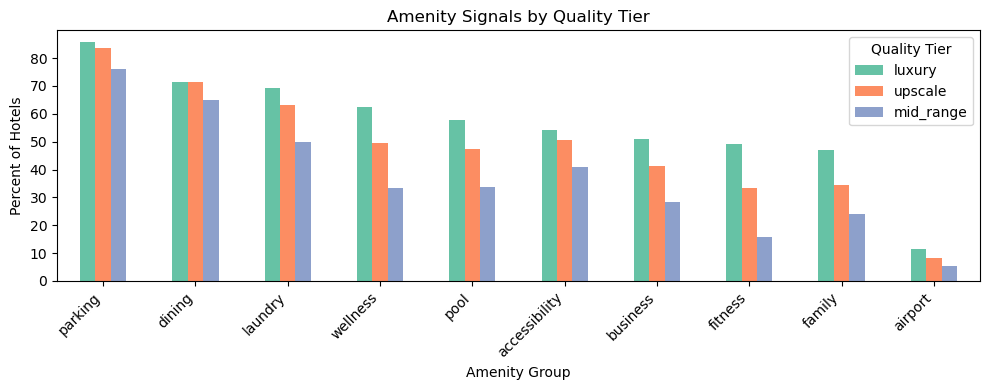

In [144]:
# Put the tiers in a natural order from lower to higher quality
amenity_compare = amenity_compare[['luxury', 'upscale','mid_range']]

amenity_compare.index = amenity_compare.index.str.replace('_amenity', '', regex=False)

colors = sns.color_palette('Set2', n_colors=len(tier_order))

# Plot amenity frequency by tier to see which signals increase with hotel quality
ax = amenity_compare.plot(
    kind='bar',
    figsize=(10, 4),
    color=colors)

ax.set_title('Amenity Signals by Quality Tier')
ax.set_xlabel('Amenity Group')
ax.set_ylabel('Percent of Hotels')
ax.legend(title='Quality Tier')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [147]:
# Calculate the percentage point difference between luxury and mid-range hotels
amenity_diff = amenity_compare.copy()

amenity_diff['luxury_minus_mid_range'] = (
    amenity_diff['luxury'] - amenity_diff['mid_range']).round(1)

# Sort so the biggest luxury differentiators show first
amenity_diff = amenity_diff.sort_values('luxury_minus_mid_range', ascending=False)

amenity_diff[['luxury', 'mid_range', 'luxury_minus_mid_range']]

quality_tier,luxury,mid_range,luxury_minus_mid_range
fitness,49.0,15.9,33.1
wellness,62.4,33.3,29.1
pool,57.7,33.8,23.9
family,47.1,24.1,23.0
business,50.8,28.2,22.6
laundry,69.2,49.8,19.4
accessibility,54.2,41.0,13.2
parking,85.7,76.2,9.5
dining,71.5,65.1,6.4
airport,11.6,5.4,6.2


### Analysis: 

Key amenities groups that separate luxury from mid-range are: fitness, wellness, pool, family, business, and laundry.

## Market-Level Amenity Gaps

Now that I have a better sense of which amenities show up more often in higher-rated hotels, I want to compare those signals by city. This helps me look for markets that have hotel volume, but may be missing certain higher-end amenity patterns like wellness, fitness, pools, or business facilities.

In [150]:
# Focus on the amenity groups that showed the clearest luxury signal
focus_amenities = [
    'fitness_amenity',
    'wellness_amenity',
    'pool_amenity',
    'family_amenity']

In [153]:
# Summarize amenity presence by city to compare markets more directly
city_amenities = amenity_df.groupby(['country_name', 'city_name']).agg(
    total_hotels=('hotel_code', 'count'),
    luxury_hotels=('quality_tier', lambda x: (x == 'luxury').sum()),
    fitness_pct=('fitness_amenity', 'mean'),
    wellness_pct=('wellness_amenity', 'mean'),
    pool_pct=('pool_amenity', 'mean'),
    family_pct=('family_amenity', 'mean')).reset_index()

# Convert amenity columns into percentages
pct_cols = ['fitness_pct', 'wellness_pct', 'pool_pct', 'family_pct']

city_amenities[pct_cols] = (
    city_amenities[pct_cols]
    .mul(100)
    .round(1))

city_amenities.head()

,country_name,city_name,total_hotels,luxury_hotels,fitness_pct,wellness_pct,pool_pct,family_pct
0,Albania,Albanien,450,26,11.8,27.6,20.4,45.3
1,Albania,Berat,32,0,3.1,12.5,0.0,25.0
2,Albania,Borsh,7,0,0.0,0.0,14.3,57.1
3,Albania,Bërxullë,1,0,0.0,100.0,0.0,0.0
4,Albania,Dhërmi,30,2,0.0,10.0,33.3,63.3


In [155]:
# Create one score to summarize higher-end amenity presence by city
city_amenities['luxury_amenity_signal'] = (
    city_amenities[pct_cols].mean(axis=1).round(1))

city_amenities.sort_values('luxury_amenity_signal', ascending=False).head()

,country_name,city_name,total_hotels,luxury_hotels,fitness_pct,wellness_pct,pool_pct,family_pct,luxury_amenity_signal
18369,Italy,Poltu Quatu,2,2,100.0,100.0,100.0,100.0,100.0
34885,United States,"Stanley, North Dakota",1,0,100.0,100.0,100.0,100.0,100.0
7547,France,Champillon,1,1,100.0,100.0,100.0,100.0,100.0
28797,Turkey,Abant,1,1,100.0,100.0,100.0,100.0,100.0
17729,Italy,Maida,1,0,100.0,100.0,100.0,100.0,100.0


In [163]:
# Find larger markets with lower luxury-style amenity signals
amenity_gap_markets = city_amenities[
    (city_amenities['total_hotels'] >= 50) &
    (city_amenities['luxury_amenity_signal'] < 40)].sort_values(['total_hotels', 'luxury_amenity_signabl'], ascending=[False, True])

amenity_gap_markets.head(20)

,country_name,city_name,total_hotels,luxury_hotels,fitness_pct,wellness_pct,pool_pct,family_pct,luxury_amenity_signal
30261,United Kingdom,London,4979,251,9.1,15.2,2.5,7.3,8.5
29603,United Kingdom,Cornwall,1997,247,2.9,7.9,11.2,7.8,7.4
18609,Italy,Rome,1531,40,13.7,36.0,8.8,22.1,20.2
975,Australia,"Melbourne, Victoria",1500,52,34.7,34.3,31.7,7.9,27.2
33584,United States,"Maui, Hawaii",1402,8,28.1,27.0,77.5,4.9,34.4
24637,South Africa,Johannesburg,1262,82,19.8,41.7,69.3,22.7,38.4
1354,Australia,"Sydney, New South Wales",1126,65,24.0,30.7,28.0,8.7,22.8
15061,India,"Bangalore, Karnataka",1126,52,24.8,54.0,15.7,22.2,29.2
24665,South Africa,Kwazulu Natal,1090,43,10.5,35.0,71.8,33.4,37.7
25808,Spain,Gran Canaria,1070,28,14.2,22.3,47.3,17.2,25.2


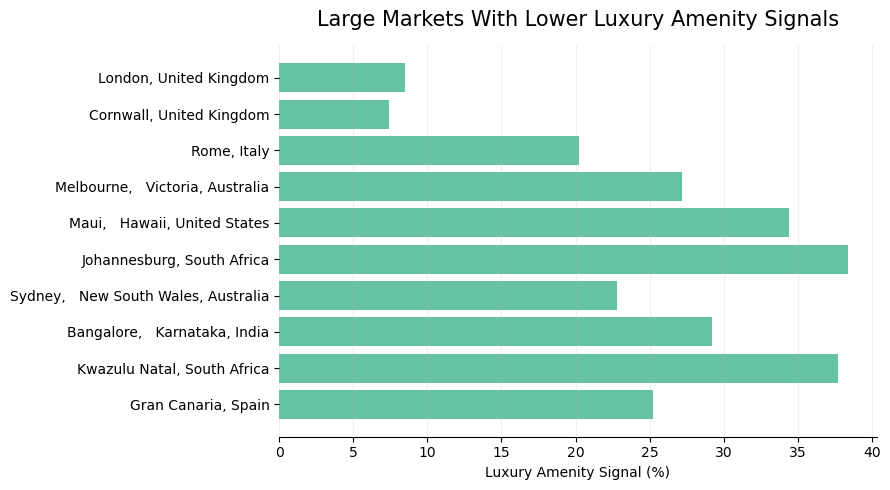

In [237]:
# Show the lowest luxury amenity signals among larger hotel markets
bar_df = (
    amenity_gap_markets
    .sort_values(['total_hotels', 'luxury_amenity_signal'], ascending=[False, True])
    .head(10)
    .copy()
)

bar_df['market'] = bar_df['city_name'] + ', ' + bar_df['country_name']

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    bar_df['market'][::-1],
    bar_df['luxury_amenity_signal'][::-1],
    color=sns.color_palette('Set2')[0]
)

ax.set_title('Large Markets With Lower Luxury Amenity Signals', fontsize=15, pad=14)
ax.set_xlabel('Luxury Amenity Signal (%)')
ax.set_ylabel('')

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('low_luxury_amenity_signal_markets.png', dpi=300, bbox_inches='tight')
plt.show()

In [158]:
# Set the amenity mix for a luxury-family hotel concept
concept_cols = ['wellness_pct', 'pool_pct', 'family_pct', 'fitness_pct']

# Create a benchmark from all luxury hotels so I have a rough standard to compare cities against
luxury_benchmark = (
    amenity_df[amenity_df['quality_tier'] == 'luxury']
    [['wellness_amenity', 'pool_amenity', 'family_amenity', 'fitness_amenity']]
    .mean()
    .mul(100)
    .round(1))

luxury_benchmark

wellness_amenity    62.4
pool_amenity        57.7
family_amenity      47.1
fitness_amenity     49.0
dtype: float64

In [159]:
# Rename benchmark fields so they line up with the city percentage columns
benchmark_map = {
    'wellness_amenity': 'wellness_pct',
    'pool_amenity': 'pool_pct',
    'family_amenity': 'family_pct',
    'fitness_amenity': 'fitness_pct'}

luxury_benchmark = luxury_benchmark.rename(index=benchmark_map)

In [160]:
# Compare each city to the luxury benchmark for the concept amenities
concept_gap = city_amenities.copy()

for col in concept_cols:
    concept_gap[f'{col}_gap'] = luxury_benchmark[col] - concept_gap[col]

# Average the amenity gaps into one simple concept gap score
gap_cols = [f'{col}_gap' for col in concept_cols]

concept_gap['concept_amenity_gap'] = concept_gap[gap_cols].mean(axis=1).round(1)

In [161]:
# Add quality-market proof so I do not only reward places with weak hotel supply
concept_gap['upscale_luxury_hotels'] = (
    concept_gap['luxury_hotels'])

# Find cities with hotel volume, some luxury presence, and weaker luxury/family amenity signals
concept_shortlist = concept_gap[
    (concept_gap['total_hotels'] >= 50) &
    (concept_gap['luxury_hotels'] >= 5) &
    (concept_gap['concept_amenity_gap'] > 10)].sort_values('concept_amenity_gap', ascending=False)

concept_shortlist[[
    'country_name',
    'city_name',
    'total_hotels',
    'luxury_hotels',
    'wellness_pct',
    'pool_pct',
    'family_pct',
    'fitness_pct',
    'concept_amenity_gap']].head(20)

,country_name,city_name,total_hotels,luxury_hotels,wellness_pct,pool_pct,family_pct,fitness_pct,concept_amenity_gap
30693,United Kingdom,Settle,58,14,0.0,1.7,3.4,0.0,52.8
30576,United Kingdom,Pwllheli,157,14,1.3,2.5,2.5,0.6,52.3
30097,United Kingdom,Keighley,83,18,0.0,1.2,7.2,0.0,52.0
30105,United Kingdom,Keswick,428,15,2.6,1.4,3.5,1.2,51.9
29231,United Kingdom,Bakewell,66,10,4.5,0.0,4.5,0.0,51.8
29620,United Kingdom,Craven Arms,50,6,2.0,6.0,2.0,0.0,51.6
30017,United Kingdom,Holyhead,94,14,2.1,2.1,4.3,1.1,51.6
30196,United Kingdom,Leyburn,108,22,3.7,0.0,6.5,0.0,51.5
30401,United Kingdom,Narberth,70,11,7.1,1.4,2.9,0.0,51.2
30386,United Kingdom,Morpeth,148,17,4.1,2.7,3.4,1.4,51.2


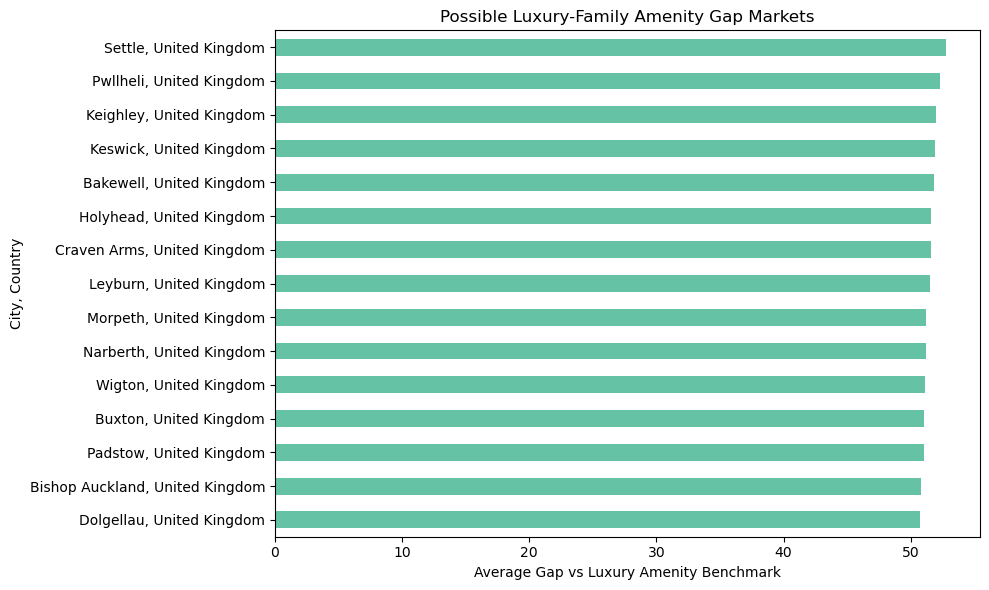

In [162]:
# Create a market label so city and country stay together in the chart
top_concept_gaps = concept_shortlist.head(15).copy()
top_concept_gaps['market'] = top_concept_gaps['city_name'] + ', ' + top_concept_gaps['country_name']

# Plot the strongest possible luxury-family amenity gaps
ax = top_concept_gaps.sort_values('concept_amenity_gap').plot(
    x='market',
    y='concept_amenity_gap',
    kind='barh',
    figsize=(10, 6),
    legend=False,
    color=sns.color_palette('Set2')[0])

ax.set_title('Possible Luxury-Family Amenity Gap Markets')
ax.set_xlabel('Average Gap vs Luxury Amenity Benchmark')
ax.set_ylabel('City, Country')

plt.tight_layout()
plt.show()

In [165]:
# Summarize family amenity signals for all hotels by city
family_market = amenity_df.groupby(['country_name', 'city_name']).agg(
    total_hotels=('hotel_code', 'count'),
    luxury_hotels=('quality_tier', lambda x: (x == 'luxury').sum()),
    family_market_pct=('family_amenity', 'mean')).reset_index()

# Convert family market signal to a percentage
family_market['family_market_pct'] = (
    family_market['family_market_pct'] * 100).round(1)

In [166]:
# Summarize family amenity signals within luxury hotels only
luxury_family = (
    amenity_df[amenity_df['quality_tier'] == 'luxury']
    .groupby(['country_name', 'city_name'])
    .agg(luxury_family_pct=('family_amenity', 'mean'))
    .reset_index())

# Convert luxury family signal to a percentage
luxury_family['luxury_family_pct'] = (
    luxury_family['luxury_family_pct'] * 100).round(1)

In [167]:
# Combine overall family demand signal with luxury-family amenity signal
family_gap = family_market.merge(
    luxury_family,
    on=['country_name', 'city_name'],
    how='left')

# Fill missing luxury-family values where a city has no matching luxury family signal
family_gap['luxury_family_pct'] = family_gap['luxury_family_pct'].fillna(0)

In [169]:
# Calculate the gap between general family signal and luxury family signal
family_gap['family_luxury_gap'] = (
    family_gap['family_market_pct'] - family_gap['luxury_family_pct']).round(1)

# Filter for cities with enough hotel volume, luxury proof, and family demand signal
family_gap_shortlist = family_gap[
    (family_gap['total_hotels'] >= 50) &
    (family_gap['luxury_hotels'] >= 5) &
    (family_gap['family_market_pct'] >= 20) &
    (family_gap['family_luxury_gap'] > 10)].sort_values('family_luxury_gap', ascending=False)

family_gap_shortlist.head(20)

,country_name,city_name,total_hotels,luxury_hotels,family_market_pct,luxury_family_pct,family_luxury_gap
22239,Peru,Lima,279,9,32.6,0.0,32.6
22226,Peru,Cuzco,291,5,30.9,0.0,30.9
18264,Italy,Perugia,360,9,41.1,11.1,30.0
5702,Croatia,Malinska,208,11,36.1,9.1,27.0
20418,Malta,Sliema,92,5,26.1,0.0,26.1
3799,Bulgaria,Golden Sands,99,6,73.7,50.0,23.7
2785,Belgium,Ghent,73,5,23.3,0.0,23.3
3296,Brazil,Curitiba,134,5,22.4,0.0,22.4
30725,United Kingdom,Skegness,92,7,21.7,0.0,21.7
31011,United Kingdom,Weston-super-Mare,71,7,21.1,0.0,21.1


In [170]:
family_gap_shortlist.shape

(26, 7)

### Analysis: 

These cities have some family-oriented hotel demand and some existing luxury supply, but the luxury hotels in the dataset do not show family-focused amenities. This could point to possible luxury-family positioning gaps, but it would need more in depth research before calling it a real market opportunity.

In [172]:
# Test stricter filters so I can see which markets stay relevant
family_gap_filtered = family_gap[
    (family_gap['total_hotels'] >= 75) &
    (family_gap['luxury_hotels'] >= 10) &
    (family_gap['family_market_pct'] >= 20) &
    (family_gap['family_luxury_gap'] > 10)].copy()

family_gap_filtered.sort_values('family_luxury_gap', ascending=False).head(20)

,country_name,city_name,total_hotels,luxury_hotels,family_market_pct,luxury_family_pct,family_luxury_gap
5702,Croatia,Malinska,208,11,36.1,9.1,27.0
12175,Germany,Lübeck,83,26,22.9,3.8,19.1
21715,New Zealand,Nelson,104,15,22.1,6.7,15.4
17875,Italy,Mestre,143,21,26.6,14.3,12.3


In [174]:
# Create a balanced score that rewards family demand, luxury proof, and the family-luxury gap
family_gap_filtered['family_opportunity_score'] = (
    family_gap_filtered['family_market_pct'] * 0.4 +
    family_gap_filtered['family_luxury_gap'] * 0.4 +
    family_gap_filtered['luxury_hotels'] * 0.2).round(1)

family_gap_filtered.sort_values('family_opportunity_score', ascending=False).head(20)

,country_name,city_name,total_hotels,luxury_hotels,family_market_pct,luxury_family_pct,family_luxury_gap,family_opportunity_score
5702,Croatia,Malinska,208,11,36.1,9.1,27.0,27.4
12175,Germany,Lübeck,83,26,22.9,3.8,19.1,22.0
17875,Italy,Mestre,143,21,26.6,14.3,12.3,19.8
21715,New Zealand,Nelson,104,15,22.1,6.7,15.4,18.0


In [182]:
# Inspect luxury hotels in one shortlisted city before trusting the market signal
city = 'Lima'
country = 'Peru'

df[
    (df['city_name'].eq(city)) &
    (df['country_name'].eq(country)) &
    (df['quality_tier'].eq('luxury'))
][[
    'hotel_name',
    'HotelWebsiteUrl',
    'star_rating',
    'hotel_facilities',
    'description'
]]

,hotel_name,HotelWebsiteUrl,star_rating,hotel_facilities,description
579499,Meliá Lima,http://www.melia.com/,5.0,Gift shops or newsstand Dry cleaning/laundry service Wheelchair accessible (may have limitations) Ballroom Reception hall Eco-friendly cleaning products used Express check-in Meeting rooms Conference space size (meters) - 20 Free wired Internet Limo or Town Car service available Free WiFi Number of bars/lounges - 1 Braille or raised signage Number of outdoor pools - 1 In-room accessibility (in select rooms) Wheelchair accessible parking Roll-in shower (in select rooms) Wedding services Tours/ticket assistance Accessible bathroom (in select rooms) Rooftop terrace Airport transportation (surcharge) Eco-friendly toiletries Eco-friendly cleaning products provided Luggage storage Express check-out Porter/bellhop Multilingual staff Business center 24-hour front desk Breakfast available (surcharge) Safe-deposit box at front desk Smoke-free property Number of coffee shops/cafes - 1 Laundry facilities Steam room elevator Free self parking Fitness facilities Conference space Terrace Conference space size (feet) - 215 Concierge services,"<p>HeadLine : In Lima (San Isidro)</p><p>Location : With a stay at Melia Lima in Lima (San Isidro), you ll be within a 5-minute drive of Huaca Huallamarca Pyramid and Lima Golf Club. This 5-star hotel is 1.6 mi (2.6 km) from National Museum of the Archaeology Anthropology and History of Peru and 1.9 mi (3.1 km) from Olivar Park.</p><p>Rooms : Make yourself at home in one of the 180 air-conditioned rooms featuring minibars and LED televisions. Complimentary wired and wireless Internet access keeps you connected, and cable programming provides entertainment. Bathrooms have complimentary toiletries and hair dryers. Conveniences include safes and desks, and housekeeping is provided daily.</p><p>Dining : Stop by the hotel s restaurant, El Tambo International, for lunch, dinner, or brunch. Dining is also available at the coffee shop/cafe, and 24-hour room service is provided. Wrap up your day with a drink at the bar/lounge. Buffet breakfasts are available daily from 6:30 AM to 10:30 AM for a fee.</p><p>CheckIn Instructions : <ul> <li>Extra-person charges may apply and vary depending on property policy</li><li>Government-issued photo identification and a cash deposit may be required at check-in for incidental charges</li><li>Special requests are subject to availability upon check-in and may incur additional charges; special requests cannot be guaranteed</li><li>Special cancellation policies or charges may apply for group reservations (more than 8 rooms for the same property / stay dates)</li><li>Guests must contact this property in advance to reserve cribs/infant beds</li><li>This property accepts credit cards, debit cards, and cash</li><li>This property uses eco-friendly cleaning products</li><li>Safety features at this property include a carbon monoxide detector, a fire extinguisher, a smoke detector, a security system, and a first aid kit</li><li>Please note that cultural norms and guest policies may differ by country and by property; the policies listed are provided by the property</li> </ul></p><p>Special Instructions : This property offers transfers from the airport (surcharges may apply). Guests must contact the property with arrival details before travel, using the contact information on the booking confirmation. Front desk staff will greet guests on arrival. At check-in, guests must provide a record of full COVID-19 vaccination. The COVID-19 vaccination record requirement applies to all guests aged 12 and up. For more details, please contact the property using the information on the booking confirmation. This property does not permit name changes on reservations. The name on the booking must match the name of the guest who is checking in and staying at the property; photo ID is required. The credit card used to book the reservation must be presented by the cardholder at check-in along with m

In [183]:
# Sshortlist of cities with hotel volume, luxury proof, and family demand
family_candidates = family_gap[
    (family_gap['total_hotels'] >= 75) &
    (family_gap['luxury_hotels'] >= 5) &
    (family_gap['family_market_pct'] >= 20) &
    (family_gap['family_luxury_gap'] > 10)].copy()

# Score markets using family demand, luxury proof, and the luxury-family gap
family_candidates['family_opportunity_score'] = (
    family_candidates['family_market_pct'] * 0.4 +
    family_candidates['family_luxury_gap'] * 0.4 +
    family_candidates['luxury_hotels'] * 0.2).round(1)

# Select the top candidate markets for deeper review
top_family_markets = (
    family_candidates
    .sort_values('family_opportunity_score', ascending=False)
    .head(10))

top_family_markets

,country_name,city_name,total_hotels,luxury_hotels,family_market_pct,luxury_family_pct,family_luxury_gap,family_opportunity_score
3799,Bulgaria,Golden Sands,99,6,73.7,50.0,23.7,40.2
18264,Italy,Perugia,360,9,41.1,11.1,30.0,30.2
15951,Ireland(Republic of),Clare,177,7,48.0,28.6,19.4,28.4
22239,Peru,Lima,279,9,32.6,0.0,32.6,27.9
5702,Croatia,Malinska,208,11,36.1,9.1,27.0,27.4
22226,Peru,Cuzco,291,5,30.9,0.0,30.9,25.7
17839,Italy,Matera,90,8,41.1,25.0,16.1,24.5
8885,France,Morzine,95,6,45.3,33.3,12.0,24.1
35523,Uruguay,Maldonado,164,6,44.5,33.3,11.2,23.5
20554,Mexico,Cuernavaca,79,5,38.0,20.0,18.0,23.4


In [184]:
# Pick one shortlisted market to inspect before trusting the score
city = 'Golden Sands'
country = 'Bulgaria'

market_luxury = df[
    (df['city_name'].eq(city)) &
    (df['country_name'].eq(country)) &
    (df['quality_tier'].eq('luxury'))
][[
    'hotel_name',
    'HotelWebsiteUrl',
    'star_rating',
    'hotel_facilities',
    'description',
]]

market_luxury

,hotel_name,HotelWebsiteUrl,star_rating,hotel_facilities,description
114660,Meliá Grand Hermitage,https://www.melia.com/en/hotels/bulgaria/varna/melia-grand-hermitage/index.html,5.0,ATM/banking Pool sun loungers Conference space size (feet) - 8934 Gift shops or newsstand Concierge services Dry cleaning/laundry service Shopping on site Renewable energy source - solar Pool umbrellas Number of meeting rooms - 7 Conference space size (meters) - 830 Sailing nearby Scuba diving nearby Free WiFi Number of bars/lounges - 4 Bicycle parking available Number of spa tubs - 1 Number of poolside bars - 2 Number of outdoor pools - 4 Number of beach bars - 1 Number of indoor pools - 1 Water skiing nearby In-room accessibility (in select rooms) Bicycle rentals nearby Wheelchair accessible parking Tours/ticket assistance Accessible bathroom (in select rooms) Free Buffet Breakfast Airport transportation (surcharge) Eco-friendly toiletries LED light bulbs Free breakfast Multilingual staff Parasailing nearby Daily Turkish bath/Hammam Coffee/tea in common areas Number of coffee shops/cafes - 1 Laundry facilities elevator Children's club (free) Fitness facilities Bicycle rentals on site Wheelchair accessible (may have limitations) Composting Wheelchair-accessible registration desk Television in common areas Windsurfing nearby Arcade/game room Spa treatment room(s) Garden Full-service spa Wedding services Yoga classes/instruction on site Luggage storage Private beach nearby Porter/bellhop Billiards or pool table Business center 24-hour front desk Archery on site Library Playground on site Spa services on site Outdoor seasonal pool Safe-deposit box at front desk Smoke-free property Snack bar/deli Children's pool Sauna Surfing/bodyboarding nearby Steam room Conference space Self parking (surcharge) Waterslide Hair salon Terrace,"<p>HeadLine : Near Golden Sands Beach</p><p>Location : Located in Golden Sands, Melia Grand Hermitage - All Inclusive is near the beach, a 3-minute walk from Golden Sands Beach and within a 5-minute drive of Aquapolis. This 5-star property is 1.2 mi (2 km) from Golden Sands Yacht Port and 1.3 mi (2.1 km) from Minigolf course.</p><p>Rooms : Make yourself at home in one of the 727 guestrooms featuring minibars and flat-screen televisions. Rooms have private balconies. Complimentary wireless Internet access keeps you connected, and satellite programming is available for your entertainment. Private bathrooms with separate bathtubs and showers feature deep soaking bathtubs and complimentary toiletries.</p><p>Dining : This property is all inclusive. Rates include meals and beverages at onsite dining establishments. Charges may be applied for dining at some restaurants, special dinners and dishes, some beverages, and other amenities. <p>Grab a bite at The Level Restaurant, one of the property s 3 restaurants, or stay in and take advantage of the 24-hour room service. Snacks are also available at the coffee shop/cafe. When you are in need of a refreshing drink, visit the beach bar or one of 4 bars/lounges, or 2 poolside bars. A complimentary buffet breakfast is served daily from 7:30 AM to 10:00 AM. </p></p><p>Renovations : The following facilities will be closed during the winter: <ul><li>Swimming pool</li></ul></p><p>CheckIn Instructions : <ul> <li>Extra-person charges may apply and vary depending on property policy</li><li>Government-issued photo identification and a credit card, debit card, or cash deposit may be required at check-in for incidental charges</li><li>Special requests are subject to availability upon check-in and may incur additional charges; special requests cannot be guaranteed</li><li>Special cancellation policies or charges may apply for group reservations (more than 8 rooms for the same property / stay dates)</li><li>Guests must contact this property in advance to reserve cribs/infant beds</li><li>This property accepts credit cards, debit cards, and cash</li><li>This property uses solar energy</li><li>Safety featu

### Manual Research:

1. Are the luxury hotels actually luxury?
Check names, star ratings, facilities, and descriptions. If the “luxury” hotels look like small inns, guesthouses, or questionable listings, the market signal is weaker.

2. Are family amenities truly missing, or just not written in the data?
Look for terms like family rooms, children, kids, babysitting, childcare, playground, connecting rooms, suites, pool, laundry, kitchen, villa, apartment. If none appear, the gap may be real. If they appear in descriptions but not facilities, your keyword logic may need adjusting.

3. Does the city type make sense for family-luxury travel?
A place like Golden Sands, Lima, Cuzco, Matera, or Clare may make more intuitive sense than a random business city. You are asking: “Would families plausibly visit here for leisure?”

4. Is the gap useful or just obvious?
For example, if luxury hotels lack family amenities because they are historic boutique hotels, adults-only resorts, or business hotels, that could actually support your story: luxury exists, but not family-oriented luxury.


---

**Best for luxury-family concept**

Golden Sands, Malinska, Morzine, Maldonado, and Cuernavaca

**Best urban setting for luxury-family concept**

Lima

**Best cultural/adventure for luxury-family concept with older kids**

Perugia, Matera, Clare, and Cuzco are interesting, but they lean more cultural/adventure and may work better for older children.

Here are five candidate markets where the dataset suggests potential for multigenerational luxury travel. These places already show hotel demand, some luxury supply, and broader family-oriented signals, but luxury-family amenities appear less represented.

In [186]:
# Limit the analysis to the five strongest candidate markets based on manual research
target_markets = [
    ('Bulgaria', 'Golden Sands'),
    ('Italy', 'Perugia'),
    ('Ireland(Republic of)', 'Clare'),
    ('Peru', 'Lima'),
    ('Croatia', 'Malinska')]

target_df = pd.DataFrame(target_markets, columns=['country_name', 'city_name'])

In [187]:
# Pull the selected markets from the family gap results
selected_markets = family_gap.merge(
    target_df,
    on=['country_name', 'city_name'],
    how='inner')

selected_markets

,country_name,city_name,total_hotels,luxury_hotels,family_market_pct,luxury_family_pct,family_luxury_gap
0,Bulgaria,Golden Sands,99,6,73.7,50.0,23.7
1,Croatia,Malinska,208,11,36.1,9.1,27.0
2,Ireland(Republic of),Clare,177,7,48.0,28.6,19.4
3,Italy,Perugia,360,9,41.1,11.1,30.0
4,Peru,Lima,279,9,32.6,0.0,32.6


In [193]:
# Calculate quality tier mix for each selected market
tier_mix = (
    df.merge(target_df, on=['country_name', 'city_name'], how='inner')
    .groupby(['country_name', 'city_name', 'quality_tier'])
    .size()
    .reset_index(name='hotel_count'))

# Convert tier counts into percentages within each market
tier_mix['tier_pct'] = (
    tier_mix['hotel_count'] /
    tier_mix.groupby(['country_name', 'city_name'])['hotel_count'].transform('sum') *
    100).round(1)

In [194]:
# Pivot tier mix so each quality tier becomes its own column
tier_pivot = tier_mix.pivot_table(
    index=['country_name', 'city_name'],
    columns='quality_tier',
    values='tier_pct',
    fill_value=0).reset_index()

# Combine hotel counts, family gap metrics, and quality tier mix into one table
market_overview = selected_markets.merge(
    tier_pivot,
    on=['country_name', 'city_name'],
    how='left')

market_overview

,country_name,city_name,total_hotels,luxury_hotels,family_market_pct,luxury_family_pct,family_luxury_gap,budget,luxury,mid_range,unrated,upscale
0,Bulgaria,Golden Sands,99,6,73.7,50.0,23.7,12.9,4.5,31.1,12.1,39.4
1,Croatia,Malinska,208,11,36.1,9.1,27.0,0.4,4.4,55.2,17.1,23.0
2,Ireland(Republic of),Clare,177,7,48.0,28.6,19.4,4.0,2.8,44.8,24.6,23.8
3,Italy,Perugia,360,9,41.1,11.1,30.0,21.1,1.6,43.8,15.6,17.9
4,Peru,Lima,279,9,32.6,0.0,32.6,24.9,1.9,46.8,17.0,9.4


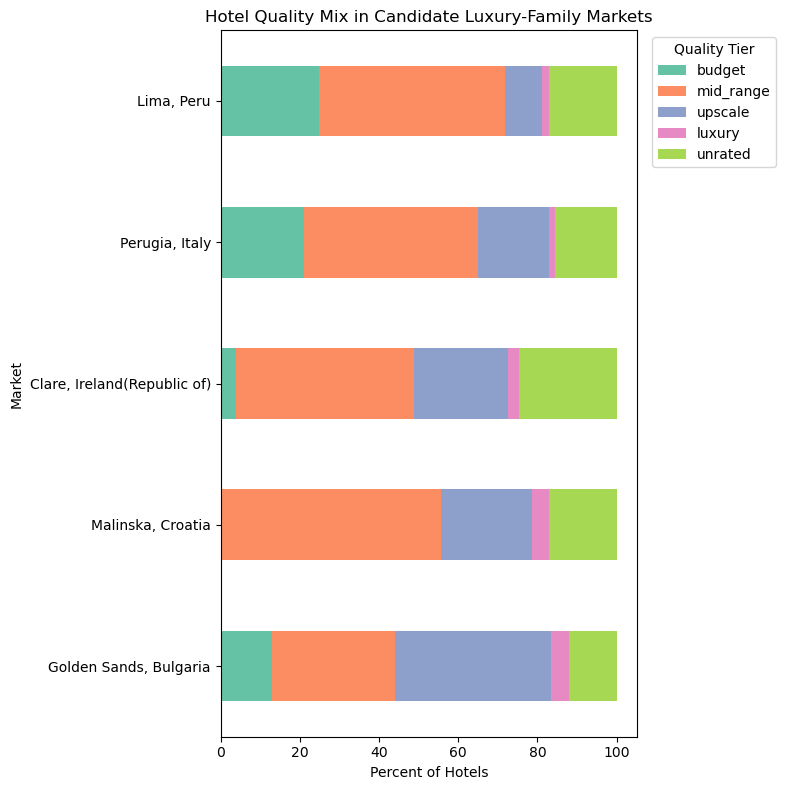

In [239]:
# Create a market label
tier_plot = tier_pivot.copy()
tier_plot['market'] = tier_plot['city_name'] + ', ' + tier_plot['country_name']

# Reorder columns so quality tiers read from lower to higher quality
tier_order = ['budget', 'mid_range', 'upscale', 'luxury', 'unrated']
tier_plot = tier_plot.set_index('market')[tier_order]

# Plot quality tier percentages for the five candidate markets
colors = sns.color_palette('Set2', n_colors=len(tier_order))

ax = tier_plot.plot(
    kind='barh',
    stacked=True,
    figsize=(8,8),
    color=colors)

ax.set_title('Hotel Quality Mix in Candidate Luxury-Family Markets')
ax.set_xlabel('Percent of Hotels')
ax.set_ylabel('Market')
ax.legend(title='Quality Tier', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Plot the family-luxury gap for the selected markets
gap_plot = selected_markets.copy()
gap_plot['market'] = gap_plot['city_name'] + ', ' + gap_plot['country_name']

ax = gap_plot.sort_values('family_luxury_gap').plot(
    x='market',
    y='family_luxury_gap',
    kind='barh',
    figsize=(9, 5),
    legend=False,
    color=sns.color_palette('Set2')[0])

ax.set_title('Family-Luxury Amenity Gap in Selected Markets')
ax.set_xlabel('Percentage Point Gap')
ax.set_ylabel('Market')

plt.tight_layout()
plt.show()

### Analysis: 

The dataset suggests five candidate markets where multigenerational luxury travel may be worth deeper research: Golden Sands, Perugia, Clare, Lima, and Malinska. These markets show a mix of hotel volume, existing luxury supply, and broader family-oriented signals, but the luxury hotel segment appears less family-focused based on available facility data.

## Manual Market Validation

The scoring helped narrow the dataset, but the final shortlist still needs a basic qualitative check. I reviewed each market based on landscape, tourism draw, family fit, and whether the location makes sense for multigenerational luxury travel.

| Market | Landscape / Setting | Tourism Draw | Family Fit | Candidate Strength |
|---|---|---|---|---|
| Golden Sands, Bulgaria | Coastal Black Sea resort | Beaches, pools, resort travel, summer leisure | Strong fit for young kids, older kids, and multigenerational beach trips | Strong |
| Perugia, Italy | Historic hilltop city in Umbria | Food, culture, architecture, day trips, slow travel | Better for older children and culture-focused families | Maybe |
| Clare, Ireland | Coastal/rural county with cliffs and countryside | Cliffs of Moher, Wild Atlantic Way, villages, nature | Good for outdoorsy families and older children | Maybe / Strong |
| Lima, Peru | Large coastal capital city | Food, museums, coastal parks, culture, Peru gateway travel | Works as an urban luxury-family base if hotel amenities are strong | Maybe / Strong |
| Malinska, Croatia | Seaside resort town on Krk Island | Beaches, promenade, island travel, relaxed leisure | Strong fit for young kids, older kids, and family resort travel | Strong |

## Limits + Issues

This analysis is used best as a pre-screening tool to help identify markets that are not overly saturated, but still show demand. 

It includes  information about hotel location, star rating, and facilities, but it does not include ADR, occupancy, RevPAR, booking demand, guest reviews, seasonality, tourism growth, traveler demographics, hotel age, or hotel types. 

The family-luxury gap score is based on facility text, so it could have missed hotels where specific words weren't included. It may also overstate gaps if facility data is incomplete.

There was also a high volume of unrated hotels.
## Final Takeaway

Because of these limitations, the final candidate markets should be understood as places worth deeper research, not final recommendations for development. 
The next step would be to validate these markets with external data (ADR, occupancy, tourism volume, airport access, family travel demand, and comp hotels). 

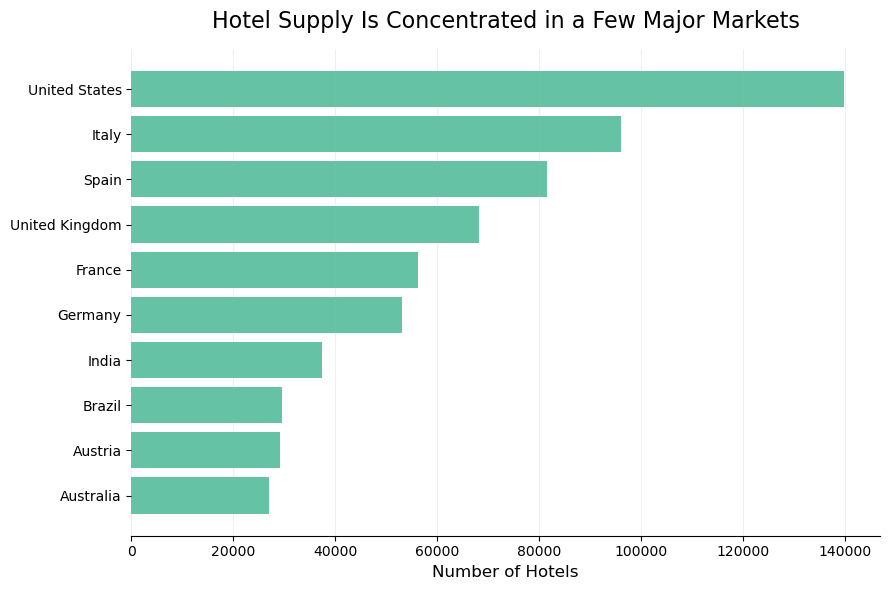

In [207]:
# Count top countries by hotel volume for a cleaner presentation chart
top_countries = df['country_name'].value_counts().head(10).sort_values()

colors = sns.color_palette('Set2', n_colors=1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_countries.index, top_countries.values, color=colors[0])

ax.set_title('Hotel Supply Is Concentrated in a Few Major Markets', fontsize=16, pad=15)
ax.set_xlabel('Number of Hotels', fontsize=12)
ax.set_ylabel('')

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('top_countries_hotel_count.png', dpi=300, bbox_inches='tight')
plt.show()

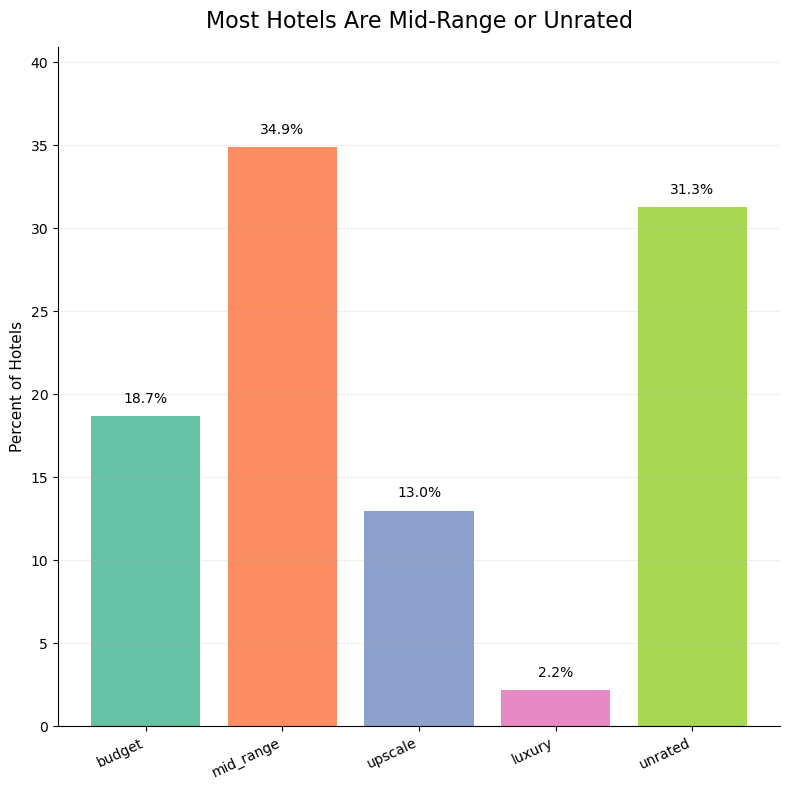

In [211]:
# Calculate quality tier share so the chart shows proportion, not just volume
tier_share = (
    df['quality_tier']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# Order tiers from lower to higher quality, with unrated last
tier_order = ['budget', 'mid_range', 'upscale', 'luxury', 'unrated']
tier_share = tier_share.reindex(tier_order).dropna()

# Use soft colors that fit the presentation style
colors = sns.color_palette('Set2', n_colors=len(tier_share))

fig, ax = plt.subplots(figsize=(8, 8))

ax.bar(tier_share.index, tier_share.values, color=colors)

ax.set_title('Most Hotels Are Mid-Range or Unrated', fontsize=16, pad=14)
ax.set_xlabel('')
ax.set_ylabel('Percent of Hotels', fontsize=11)

# Add percentage labels so the values are easy to read
for i, value in enumerate(tier_share.values):
    ax.text(i, value + 0.8, f'{value:.1f}%', ha='center', fontsize=10)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.set_ylim(0, tier_share.max() + 6)

plt.xticks(rotation=25, ha='right')
plt.tight_layout()

plt.savefig('quality_tier_distribution_vertical.png', dpi=300, bbox_inches='tight')
plt.show()